# Customer Profile Analysis

**Project:** StudyBuild online-store customer analysis  
**Phase:** Phase 2 - exploratory customer analysis  
**Input:** `data/cleaned_dataset_FatemehDehghan224.xlsx`

This notebook starts the second phase of the project. It uses the cleaned customer dataset from Phase 1 and answers the first business question through a focused exploratory analysis. Each question should remain in its own section so future questions can be added without mixing code, charts, or conclusions.

## 0. Environment and Project Paths

This setup section imports the required libraries, uses a non-interactive Matplotlib backend when the notebook is executed as a script, and locates the project root from either the repository root or the `analysis_code/` folder. The analysis only reads the cleaned dataset produced by the cleaning pipeline.

In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib

try:
    from IPython import get_ipython
except ImportError:
    get_ipython = lambda: None

if get_ipython() is None:
    matplotlib.use("Agg")

import matplotlib.pyplot as plt
import pandas as pd

try:
    from IPython.display import display
except ImportError:
    def display(value: object) -> None:
        """Print a value when IPython display is unavailable."""
        print(value)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)


def find_project_root(start: Path) -> Path:
    """Return the nearest parent directory that contains the cleaned dataset."""
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        cleaned_path = candidate / "data" / "cleaned_dataset_FatemehDehghan224.xlsx"
        if cleaned_path.exists():
            return candidate
    raise FileNotFoundError(
        "Could not find data/cleaned_dataset_FatemehDehghan224.xlsx from the current path."
    )


PROJECT_ROOT = find_project_root(Path.cwd())
DATA_DIR = PROJECT_ROOT / "data"
CLEANED_DATA_PATH = DATA_DIR / "cleaned_dataset_FatemehDehghan224.xlsx"

REQUIRED_COLUMNS = [
    "customer_id",
    "gender",
    "age",
    "membership_tier",
    "device",
    "payment_method",
]

PROJECT_ROOT, CLEANED_DATA_PATH

(WindowsPath('F:/Data Analysis/studybuild-customer-analysis-02/submissions/FatemehDehghan224'),
 WindowsPath('F:/Data Analysis/studybuild-customer-analysis-02/submissions/FatemehDehghan224/data/cleaned_dataset_FatemehDehghan224.xlsx'))

## Question 1 - Main Customer Profile

**Business question:** Who are the store's main customers?

Before designing an advertising campaign, management needs a clear picture of current customers. This section analyzes the requested customer characteristics: `gender`, `age`, `membership_tier`, `device`, and `payment_method`.

The expected outputs are:

- A concise summary table of the dominant customer characteristics.
- Bar charts for age groups, membership tiers, devices, and payment methods.
- A final paragraph that describes the main customer profile based only on the cleaned data.

### 1. Load and Validate the Cleaned Dataset

The analysis starts from the cleaned Excel workbook exported by Phase 1. The code checks that all columns required for this question are available before any chart or summary is created.

In [2]:
def load_cleaned_customer_data(path: Path) -> pd.DataFrame:
    """Load the cleaned customer workbook and validate the question-specific columns.

    Args:
        path: Path to the cleaned Excel workbook produced by the cleaning phase.

    Returns:
        A pandas DataFrame containing the cleaned customer records.

    Raises:
        FileNotFoundError: If the cleaned workbook does not exist.
        ValueError: If one or more required analysis columns are missing.
    """
    if not path.exists():
        raise FileNotFoundError(f"Cleaned dataset was not found: {path}")

    df = pd.read_excel(path, sheet_name="customers")
    missing_columns = sorted(set(REQUIRED_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing required columns: {missing_columns}")
    return df


customer_df = load_cleaned_customer_data(CLEANED_DATA_PATH)

load_summary = pd.DataFrame(
    {
        "metric": ["rows", "columns", "unique_customers", "duplicate_customer_ids"],
        "value": [
            len(customer_df),
            customer_df.shape[1],
            customer_df["customer_id"].nunique(),
            int(customer_df["customer_id"].duplicated().sum()),
        ],
    }
)
display(load_summary)

display(customer_df[REQUIRED_COLUMNS].head())

,metric,value
0,rows,60
1,columns,17
2,unique_customers,60
3,duplicate_customer_ids,0


,customer_id,gender,age,membership_tier,device,payment_method
0,1001,1,19,VIP,Android,Card
1,1002,1,53,Gold,Web,Card
2,1003,1,31,Gold,iPhone,Online Wallet
3,1004,1,58,Gold,Android,Card
4,1005,0,28,Silver,Android,Online Wallet


### 2. Prepare Analysis Columns

Only rows with complete values in the requested variables are used for this question. The cleaned dataset stores `gender` as a numeric modeling field, so this section converts it back to readable labels for reporting. Age is also converted into ordered age groups with `pd.cut()` so customers can be compared by meaningful segments.

In [3]:
GENDER_LABELS = {
    0: "Female",
    1: "Male",
    "0": "Female",
    "1": "Male",
    "F": "Female",
    "M": "Male",
    "Female": "Female",
    "Male": "Male",
}

AGE_BINS = [0, 24, 34, 44, 54, 64, float("inf")]
AGE_LABELS = ["Under 25", "25-34", "35-44", "45-54", "55-64", "65 and older"]


def prepare_customer_profile_data(df: pd.DataFrame) -> pd.DataFrame:
    """Create a complete and readable dataset for customer profile analysis.

    Args:
        df: Cleaned customer dataset.

    Returns:
        A copy of the required profile columns with readable gender labels and age groups.
    """
    profile_df = df.dropna(subset=REQUIRED_COLUMNS).copy()
    profile_df["gender_label"] = profile_df["gender"].map(GENDER_LABELS)
    profile_df["gender_label"] = profile_df["gender_label"].fillna(profile_df["gender"].astype(str))
    profile_df["age_group"] = pd.cut(
        profile_df["age"],
        bins=AGE_BINS,
        labels=AGE_LABELS,
        include_lowest=True,
    )
    return profile_df


analysis_df = prepare_customer_profile_data(customer_df)

preparation_summary = pd.DataFrame(
    {
        "metric": ["input_rows", "rows_used_for_question_1", "rows_removed_due_to_required_missing_values"],
        "value": [len(customer_df), len(analysis_df), len(customer_df) - len(analysis_df)],
    }
)
display(preparation_summary)

display(analysis_df[["customer_id", "gender_label", "age", "age_group", "membership_tier", "device", "payment_method"]].head())

,metric,value
0,input_rows,60
1,rows_used_for_question_1,60
2,rows_removed_due_to_required_missing_values,0


,customer_id,gender_label,age,age_group,membership_tier,device,payment_method
0,1001,Male,19,Under 25,VIP,Android,Card
1,1002,Male,53,45-54,Gold,Web,Card
2,1003,Male,31,25-34,Gold,iPhone,Online Wallet
3,1004,Male,58,55-64,Gold,Android,Card
4,1005,Female,28,25-34,Silver,Android,Online Wallet


### 3. Summary Table of Customer Characteristics

This table gives a compact view of each requested feature. It includes both the customer count and the percentage share, which makes it easier to compare categories even when future datasets have a different row count.

In [4]:
def build_count_share_table(
    df: pd.DataFrame,
    column: str,
    feature_name: str,
    sort_by_count: bool = True,
) -> pd.DataFrame:
    """Build a count-and-share table for one categorical customer feature.

    Args:
        df: Prepared customer profile dataset.
        column: Column name to summarize.
        feature_name: Human-readable feature name for the output table.
        sort_by_count: Whether to sort categories by customer count in descending order.

    Returns:
        A DataFrame with category counts and percentage shares.
    """
    counts = df[column].value_counts(sort=False, dropna=False)
    if sort_by_count:
        counts = counts.sort_values(ascending=False)

    result = counts.rename_axis("category").reset_index(name="customer_count")
    result.insert(0, "feature", feature_name)
    result["share_percent"] = (result["customer_count"] / len(df) * 100).round(1)
    return result


profile_tables = [
    build_count_share_table(analysis_df, "gender_label", "Gender"),
    build_count_share_table(analysis_df, "age_group", "Age group", sort_by_count=False),
    build_count_share_table(analysis_df, "membership_tier", "Membership tier"),
    build_count_share_table(analysis_df, "device", "Device"),
    build_count_share_table(analysis_df, "payment_method", "Payment method"),
]

customer_characteristics_table = pd.concat(profile_tables, ignore_index=True)
display(customer_characteristics_table)

,feature,category,customer_count,share_percent
0,Gender,Male,35,58.3
1,Gender,Female,25,41.7
2,Age group,Under 25,7,11.7
3,Age group,25-34,11,18.3
4,Age group,35-44,10,16.7
5,Age group,45-54,15,25.0
6,Age group,55-64,16,26.7
7,Age group,65 and older,1,1.7
8,Membership tier,Gold,19,31.7
9,Membership tier,Bronze,18,30.0


In [5]:
def summarize_customer_profile(df: pd.DataFrame) -> pd.Series:
    """Calculate the dominant values needed for the final customer profile answer.

    Args:
        df: Prepared customer profile dataset.

    Returns:
        A named pandas Series containing the main profile metrics.
    """
    age_counts = df["age_group"].value_counts(sort=False)
    gender_counts = df["gender_label"].value_counts()
    membership_counts = df["membership_tier"].value_counts()
    device_counts = df["device"].value_counts()
    payment_counts = df["payment_method"].value_counts()

    return pd.Series(
        {
            "customer_count": df["customer_id"].nunique(),
            "mean_age": round(df["age"].mean(), 1),
            "median_age": round(df["age"].median(), 1),
            "dominant_age_group": age_counts.idxmax(),
            "dominant_age_group_count": int(age_counts.max()),
            "dominant_gender": gender_counts.idxmax(),
            "dominant_gender_count": int(gender_counts.max()),
            "dominant_membership_tier": membership_counts.idxmax(),
            "dominant_membership_tier_count": int(membership_counts.max()),
            "dominant_device": device_counts.idxmax(),
            "dominant_device_count": int(device_counts.max()),
            "dominant_payment_method": payment_counts.idxmax(),
            "dominant_payment_method_count": int(payment_counts.max()),
        },
        name="value",
    )


profile_summary = summarize_customer_profile(analysis_df)
display(profile_summary)

customer_count                               60
mean_age                                   43.7
median_age                                 45.0
dominant_age_group                        55-64
dominant_age_group_count                     16
dominant_gender                            Male
dominant_gender_count                        35
dominant_membership_tier                   Gold
dominant_membership_tier_count               19
dominant_device                         Android
dominant_device_count                        22
dominant_payment_method           Online Wallet
dominant_payment_method_count                23
Name: value, dtype: object

### 4. Age Group Distribution

This chart shows whether the store's customer base is concentrated in younger, middle-aged, or older adult segments. Age is grouped before plotting because campaign targeting decisions are usually made by segment rather than by exact age.

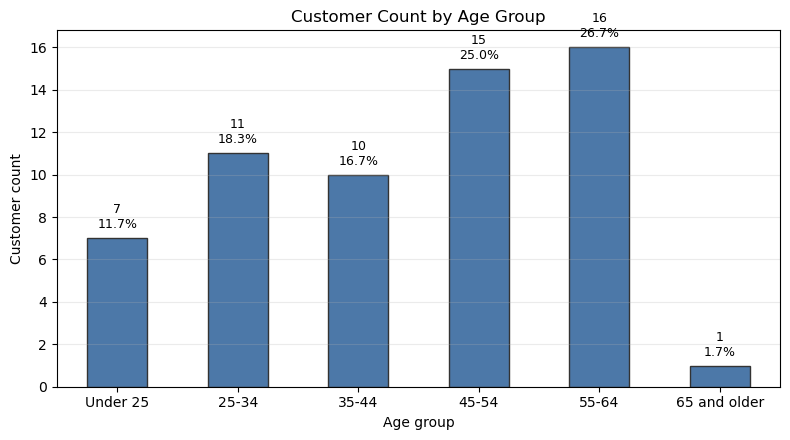

<Axes: title={'center': 'Customer Count by Age Group'}, xlabel='Age group', ylabel='Customer count'>

In [6]:
def add_bar_labels(ax: plt.Axes, total: int, orientation: str = "vertical") -> None:
    """Add count and percentage labels to a Matplotlib bar chart.

    Args:
        ax: Matplotlib axes that already contains bar patches.
        total: Total number of customers used to calculate percentages.
        orientation: Either "vertical" or "horizontal".
    """
    for patch in ax.patches:
        if orientation == "horizontal":
            count = patch.get_width()
            x = patch.get_width()
            y = patch.get_y() + patch.get_height() / 2
            ax.annotate(
                f"{int(count)} ({count / total * 100:.1f}%)",
                (x, y),
                xytext=(5, 0),
                textcoords="offset points",
                va="center",
                fontsize=9,
            )
        else:
            count = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            y = patch.get_height()
            ax.annotate(
                f"{int(count)}\n{count / total * 100:.1f}%",
                (x, y),
                xytext=(0, 5),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )


def plot_count_chart(
    counts: pd.Series,
    title: str,
    xlabel: str,
    ylabel: str,
    color: str,
    orientation: str = "vertical",
    figsize: tuple[float, float] = (8, 4.5),
) -> plt.Axes:
    """Plot a count chart with readable labels and percentage annotations.

    Args:
        counts: Category counts to plot.
        title: Chart title.
        xlabel: X-axis label.
        ylabel: Y-axis label.
        color: Bar color.
        orientation: Either "vertical" or "horizontal".
        figsize: Figure size in inches.

    Returns:
        The Matplotlib axes object for optional downstream customization.
    """
    fig, ax = plt.subplots(figsize=figsize)
    if orientation == "horizontal":
        counts.sort_values().plot(kind="barh", ax=ax, color=color, edgecolor="#333333")
        add_bar_labels(ax, total=int(counts.sum()), orientation="horizontal")
    else:
        counts.plot(kind="bar", ax=ax, color=color, edgecolor="#333333")
        add_bar_labels(ax, total=int(counts.sum()), orientation="vertical")
        ax.tick_params(axis="x", rotation=0)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(axis="y" if orientation == "vertical" else "x", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


age_counts = analysis_df["age_group"].value_counts(sort=False)
plot_count_chart(
    age_counts,
    title="Customer Count by Age Group",
    xlabel="Age group",
    ylabel="Customer count",
    color="#4C78A8",
)

### 5. Gender Distribution

Gender is included because it is one of the requested customer characteristics. The cleaned dataset stores it as a binary encoded field for modeling, but the chart uses readable labels for interpretation.

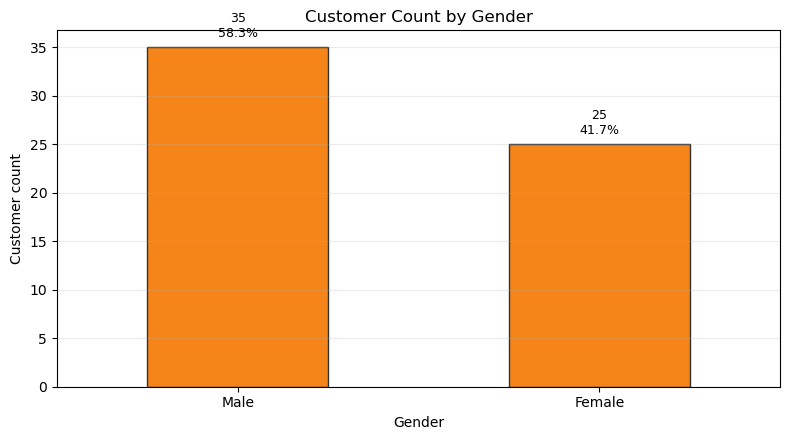

<Axes: title={'center': 'Customer Count by Gender'}, xlabel='Gender', ylabel='Customer count'>

In [7]:
gender_counts = analysis_df["gender_label"].value_counts()
plot_count_chart(
    gender_counts,
    title="Customer Count by Gender",
    xlabel="Gender",
    ylabel="Customer count",
    color="#F58518",
)

### 6. Membership Tier Distribution

This chart shows which membership tiers are most common among current customers. The result helps decide whether the campaign should focus on loyalty growth, retention, or reactivation.

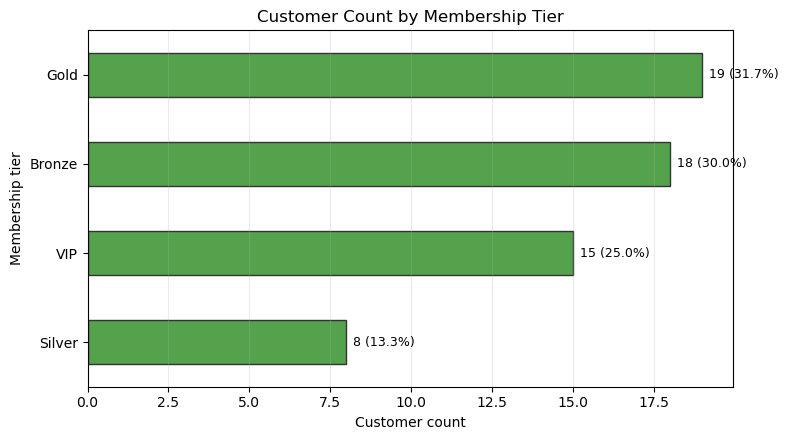

<Axes: title={'center': 'Customer Count by Membership Tier'}, xlabel='Customer count', ylabel='Membership tier'>

In [8]:
membership_counts = analysis_df["membership_tier"].value_counts()
plot_count_chart(
    membership_counts,
    title="Customer Count by Membership Tier",
    xlabel="Customer count",
    ylabel="Membership tier",
    color="#54A24B",
    orientation="horizontal",
)

### 7. Device Distribution

Device usage indicates where the campaign experience should work best. A strong device preference would suggest where landing pages, messages, and purchase flows need the most attention.

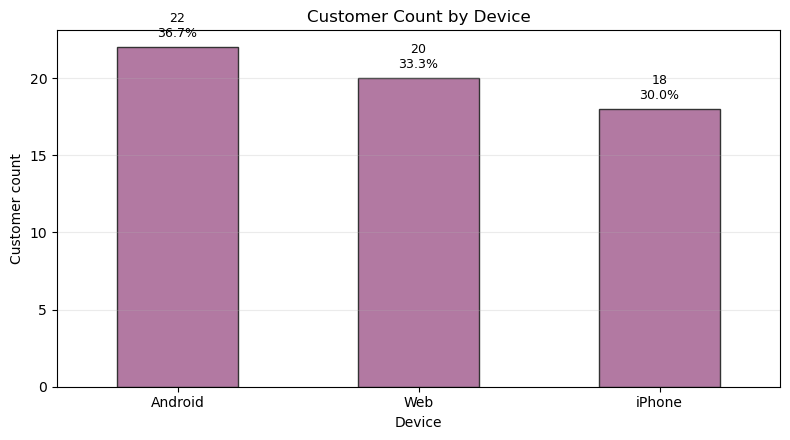

<Axes: title={'center': 'Customer Count by Device'}, xlabel='Device', ylabel='Customer count'>

In [9]:
device_counts = analysis_df["device"].value_counts()
plot_count_chart(
    device_counts,
    title="Customer Count by Device",
    xlabel="Device",
    ylabel="Customer count",
    color="#B279A2",
)

### 8. Payment Method Distribution

Payment method distribution helps identify the checkout behavior of the current customer base. This can guide campaign incentives, payment-specific offers, and checkout messaging.

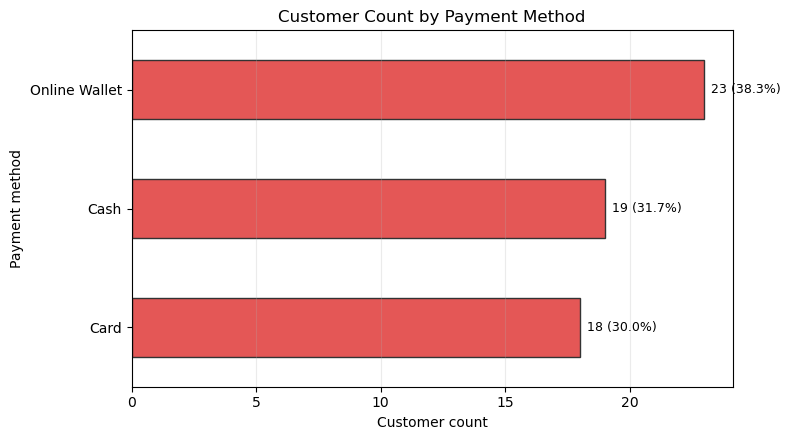

<Axes: title={'center': 'Customer Count by Payment Method'}, xlabel='Customer count', ylabel='Payment method'>

In [10]:
payment_counts = analysis_df["payment_method"].value_counts()
plot_count_chart(
    payment_counts,
    title="Customer Count by Payment Method",
    xlabel="Customer count",
    ylabel="Payment method",
    color="#E45756",
    orientation="horizontal",
)

### 9. Interpretation of the Charts

The charts answer the main exploration questions for this business request:

- The largest age segment is `55-64`, with `45-54` close behind. This means the current customer base leans toward middle-aged and older adult customers rather than very young customers.
- The customer base is majority `Male`, but the difference is not large enough to ignore female customers.
- `Gold` is the most common membership tier, with `Bronze` very close behind. This suggests both loyalty-oriented customers and lower-tier customers are important.
- `Android` is the most common device, followed closely by `Web`, so campaign assets should be checked carefully on both mobile Android and desktop/web flows.
- `Online Wallet` is the most common payment method, making wallet-based checkout messaging or incentives a reasonable first test.

In [11]:
def build_final_answer(summary: pd.Series, df: pd.DataFrame) -> str:
    """Create the final business answer from the computed customer profile summary.

    Args:
        summary: Series returned by summarize_customer_profile().
        df: Prepared customer profile dataset used for the analysis.

    Returns:
        A concise English paragraph answering the business question.
    """
    total = int(summary["customer_count"])
    dominant_age_share = summary["dominant_age_group_count"] / total * 100
    dominant_gender_share = summary["dominant_gender_count"] / total * 100
    dominant_membership_share = summary["dominant_membership_tier_count"] / total * 100
    dominant_device_share = summary["dominant_device_count"] / total * 100
    dominant_payment_share = summary["dominant_payment_method_count"] / total * 100

    return (
        f"The cleaned dataset contains {total} unique customers. The main current customer profile is a "
        f"{summary['dominant_gender']} customer in the {summary['dominant_age_group']} age group, with "
        f"{summary['dominant_membership_tier']} membership, using {summary['dominant_device']}, and most often paying "
        f"with {summary['dominant_payment_method']}. The leading age group has {summary['dominant_age_group_count']} "
        f"customers ({dominant_age_share:.1f}%), and the median customer age is {summary['median_age']:.0f}. "
        f"The leading gender has {summary['dominant_gender_count']} customers ({dominant_gender_share:.1f}%). "
        f"The leading membership tier has {summary['dominant_membership_tier_count']} customers "
        f"({dominant_membership_share:.1f}%), the leading device has {summary['dominant_device_count']} customers "
        f"({dominant_device_share:.1f}%), and the leading payment method has "
        f"{summary['dominant_payment_method_count']} customers ({dominant_payment_share:.1f}%). Because no single "
        f"category fully dominates the dataset, the campaign should prioritize adults aged 45-64, Android and web "
        f"experiences, and online-wallet checkout incentives, while still keeping the message broad enough for other "
        f"segments."
    )


final_answer = build_final_answer(profile_summary, analysis_df)
print(final_answer)

The cleaned dataset contains 60 unique customers. The main current customer profile is a Male customer in the 55-64 age group, with Gold membership, using Android, and most often paying with Online Wallet. The leading age group has 16 customers (26.7%), and the median customer age is 45. The leading gender has 35 customers (58.3%). The leading membership tier has 19 customers (31.7%), the leading device has 22 customers (36.7%), and the leading payment method has 23 customers (38.3%). Because no single category fully dominates the dataset, the campaign should prioritize adults aged 45-64, Android and web experiences, and online-wallet checkout incentives, while still keeping the message broad enough for other segments.


### 10. Final Answer

Based on the cleaned data, the store's main customers are mostly middle-aged and older adult customers, especially the `55-64` and `45-54` age groups. The dominant profile is a `Male` customer, most commonly in the `Gold` membership tier, using `Android`, and paying with `Online Wallet`.

The final campaign decision should not be too narrow because the dataset is fairly balanced across several categories. The strongest first target is customers aged `45-64`, with campaign experiences optimized for `Android` and `Web`, and with payment messaging or incentives around `Online Wallet`. `Gold` customers should be treated as the primary loyalty segment, while `Bronze` customers should also be considered because their count is very close to Gold.


## Question 2 - Selecting a Province and City for Advertising Investment

**Business question:** Which province and city are most suitable for advertising investment?

The advertising budget is limited, so the decision should balance market size, financial value, and customer satisfaction. This section evaluates cities at the combined `province`-`city` level. It reports the number of unique customers, total customer spending, average customer spending, average purchase count, average order value, and average satisfaction.

The analysis uses a minimum threshold of three unique customers per city. This reduces the risk that a very small group produces an unstable average. The final recommendation is descriptive: it identifies attractive markets in the observed data and does not claim that advertising caused the observed spending or satisfaction.

### 1. Prepare Location-Level Analysis Data

The cleaned customer dataset is used as the only source for this question. Rows with missing values in any required field are excluded before aggregation. Keeping `province` and `city` together prevents similarly named cities from being incorrectly combined across provinces.

In [12]:
LOCATION_COLUMNS = [
    "province",
    "city",
    "customer_id",
    "total_spending",
    "purchase_count",
    "avg_order_value",
    "satisfaction_score",
]
MIN_CUSTOMERS_PER_CITY = 3


def prepare_location_analysis_data(
    df: pd.DataFrame,
    required_columns: list[str] = LOCATION_COLUMNS,
) -> pd.DataFrame:
    """Return complete records for province-and-city analysis.

    Args:
        df: Cleaned customer-level dataset.
        required_columns: Columns required to calculate the location metrics.

    Returns:
        A copy containing only rows with non-missing values in the required columns.

    Raises:
        ValueError: If a required column is missing or no complete rows remain.
    """
    missing_columns = sorted(set(required_columns) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing required location-analysis columns: {missing_columns}")

    location_df = df.dropna(subset=required_columns).copy()
    if location_df.empty:
        raise ValueError("No complete rows are available for location analysis.")
    return location_df


location_df = prepare_location_analysis_data(customer_df)

location_preparation_summary = pd.DataFrame(
    {
        "metric": [
            "input_rows",
            "complete_rows_used",
            "rows_excluded_due_to_missing_values",
        ],
        "value": [
            len(customer_df),
            len(location_df),
            len(customer_df) - len(location_df),
        ],
    }
)
display(location_preparation_summary)

,metric,value
0,input_rows,60
1,complete_rows_used,60
2,rows_excluded_due_to_missing_values,0


### 2. Build the City Summary Table

The summary table combines scale and quality indicators. `total_revenue` represents the sum of customer-level `total_spending` for the city; it is not revenue from individual orders. The average metrics describe the typical customer in each city and help prevent a large customer base from being the only factor in the decision.

In [13]:
def build_city_summary(
    location_df: pd.DataFrame,
    minimum_customers: int = MIN_CUSTOMERS_PER_CITY,
) -> pd.DataFrame:
    """Aggregate customer scale, value, activity, and satisfaction by city.

    Args:
        location_df: Complete customer records prepared for location analysis.
        minimum_customers: Minimum number of unique customers required to retain a city.

    Returns:
        A city-level DataFrame with one row per province-and-city combination.

    Raises:
        ValueError: If the customer threshold is less than one or no city meets it.
    """
    if minimum_customers < 1:
        raise ValueError("minimum_customers must be at least 1.")

    city_summary = (
        location_df.groupby(["province", "city"], as_index=False)
        .agg(
            customer_count=("customer_id", "nunique"),
            total_revenue=("total_spending", "sum"),
            avg_customer_spending=("total_spending", "mean"),
            avg_purchase_count=("purchase_count", "mean"),
            avg_order_value=("avg_order_value", "mean"),
            avg_satisfaction=("satisfaction_score", "mean"),
        )
    )
    city_summary = city_summary[city_summary["customer_count"] >= minimum_customers].copy()
    if city_summary.empty:
        raise ValueError("No city meets the minimum customer threshold.")

    return city_summary.sort_values("total_revenue", ascending=False).reset_index(drop=True)


city_summary = build_city_summary(location_df)
display(city_summary.round(2))

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction
0,Khorasan Razavi,Mashhad,11,43197.58,3927.05,22.64,210.51,2.91
1,East Azerbaijan,Tabriz,12,36192.49,3016.04,15.75,238.90,3.00
2,Alborz,Karaj,7,26189.81,3741.40,16.00,211.44,2.86
3,Khuzestan,Ahvaz,8,23384.78,2923.10,13.88,216.53,3.50
4,Isfahan,Isfahan,5,21975.32,4395.06,19.80,212.68,4.40
5,Fars,Shiraz,6,20715.92,3452.65,16.33,180.98,2.00
6,Guilan,Rasht,5,15168.54,3033.71,16.40,241.55,2.60
7,Tehran,Tehran,6,15161.29,2526.88,17.17,172.93,2.67


### 3. Create a Transparent Market Priority Score

To support a budget-allocation decision, the three decision dimensions are normalized to a 0-1 scale and combined with explicit weights: 40% total customer spending, 30% average customer spending, and 30% average satisfaction. The score is a prioritization aid, not a statistical model. The individual metrics remain visible so the recommendation can be challenged or adjusted by management.

In [14]:
MARKET_PRIORITY_WEIGHTS = {
    "total_revenue": 0.40,
    "avg_customer_spending": 0.30,
    "avg_satisfaction": 0.30,
}


def add_market_priority_score(
    city_summary: pd.DataFrame,
    weights: dict[str, float] = MARKET_PRIORITY_WEIGHTS,
) -> pd.DataFrame:
    """Add a weighted, min-max-normalized score for market prioritization.

    Args:
        city_summary: City-level metrics created by build_city_summary().
        weights: Weights for total value, per-customer value, and satisfaction.

    Returns:
        A copy of city_summary with normalized driver columns and priority_score.

    Raises:
        ValueError: If required score columns are missing or weights are invalid.
    """
    required_metrics = list(weights)
    missing_metrics = sorted(set(required_metrics) - set(city_summary.columns))
    if missing_metrics:
        raise ValueError(f"Missing score metrics: {missing_metrics}")
    if any(weight < 0 for weight in weights.values()) or sum(weights.values()) <= 0:
        raise ValueError("Weights must be non-negative and have a positive total.")

    scored = city_summary.copy()
    weight_total = sum(weights.values())
    scored["priority_score"] = 0.0

    for metric, weight in weights.items():
        minimum = scored[metric].min()
        maximum = scored[metric].max()
        span = maximum - minimum
        normalized_column = f"{metric}_normalized"
        scored[normalized_column] = 1.0 if span == 0 else (scored[metric] - minimum) / span
        scored["priority_score"] += scored[normalized_column] * (weight / weight_total)

    return scored.sort_values(
        ["priority_score", "total_revenue", "avg_satisfaction", "customer_count"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)


scored_city_summary = add_market_priority_score(city_summary)
display(
    scored_city_summary[
        [
            "province",
            "city",
            "customer_count",
            "total_revenue",
            "avg_customer_spending",
            "avg_satisfaction",
            "priority_score",
        ]
    ].round(2)
)

,province,city,customer_count,total_revenue,avg_customer_spending,avg_satisfaction,priority_score
0,Khorasan Razavi,Mashhad,11,43197.58,3927.05,2.91,0.74
1,Isfahan,Isfahan,5,21975.32,4395.06,4.40,0.70
2,East Azerbaijan,Tabriz,12,36192.49,3016.04,3.00,0.50
3,Alborz,Karaj,7,26189.81,3741.40,2.86,0.46
4,Khuzestan,Ahvaz,8,23384.78,2923.10,3.50,0.37
5,Fars,Shiraz,6,20715.92,3452.65,2.00,0.23
6,Guilan,Rasht,5,15168.54,3033.71,2.60,0.16
7,Tehran,Tehran,6,15161.29,2526.88,2.67,0.08


### 4. Rank the Recommended and Alternative Markets

The primary recommendation is the highest-priority market under the stated weights. The alternative is useful for a controlled test or for management when customer satisfaction and per-customer value are more important than total market scale.

In [15]:
def select_market_recommendations(
    scored_city_summary: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """Select the primary and alternative markets from the scored table.

    Args:
        scored_city_summary: City-level table containing priority_score.

    Returns:
        A tuple containing the ranked table, the primary one-row table, and the alternative one-row table.

    Raises:
        ValueError: If the scored table is empty or lacks priority_score.
    """
    if "priority_score" not in scored_city_summary.columns or scored_city_summary.empty:
        raise ValueError("A non-empty scored city table is required.")

    ranked = scored_city_summary.sort_values(
        ["priority_score", "total_revenue", "avg_satisfaction", "customer_count"],
        ascending=[False, False, False, False],
    ).reset_index(drop=True)
    primary = ranked.head(1).copy()
    alternative = ranked.iloc[1:2].copy()
    return ranked, primary, alternative


ranked_markets, recommended_city, alternative_city = select_market_recommendations(
    scored_city_summary
)

recommendation_columns = [
    "province",
    "city",
    "customer_count",
    "total_revenue",
    "avg_customer_spending",
    "avg_purchase_count",
    "avg_order_value",
    "avg_satisfaction",
    "priority_score",
]
display(ranked_markets[recommendation_columns].round(2))

,province,city,customer_count,total_revenue,avg_customer_spending,avg_purchase_count,avg_order_value,avg_satisfaction,priority_score
0,Khorasan Razavi,Mashhad,11,43197.58,3927.05,22.64,210.51,2.91,0.74
1,Isfahan,Isfahan,5,21975.32,4395.06,19.80,212.68,4.40,0.70
2,East Azerbaijan,Tabriz,12,36192.49,3016.04,15.75,238.90,3.00,0.50
3,Alborz,Karaj,7,26189.81,3741.40,16.00,211.44,2.86,0.46
4,Khuzestan,Ahvaz,8,23384.78,2923.10,13.88,216.53,3.50,0.37
5,Fars,Shiraz,6,20715.92,3452.65,16.33,180.98,2.00,0.23
6,Guilan,Rasht,5,15168.54,3033.71,16.40,241.55,2.60,0.16
7,Tehran,Tehran,6,15161.29,2526.88,17.17,172.93,2.67,0.08


### 5. Top Cities by Total Customer Spending

This horizontal bar chart ranks the largest retained city markets by total customer spending. It is a scale view and should be interpreted together with the average spending and satisfaction metrics below.

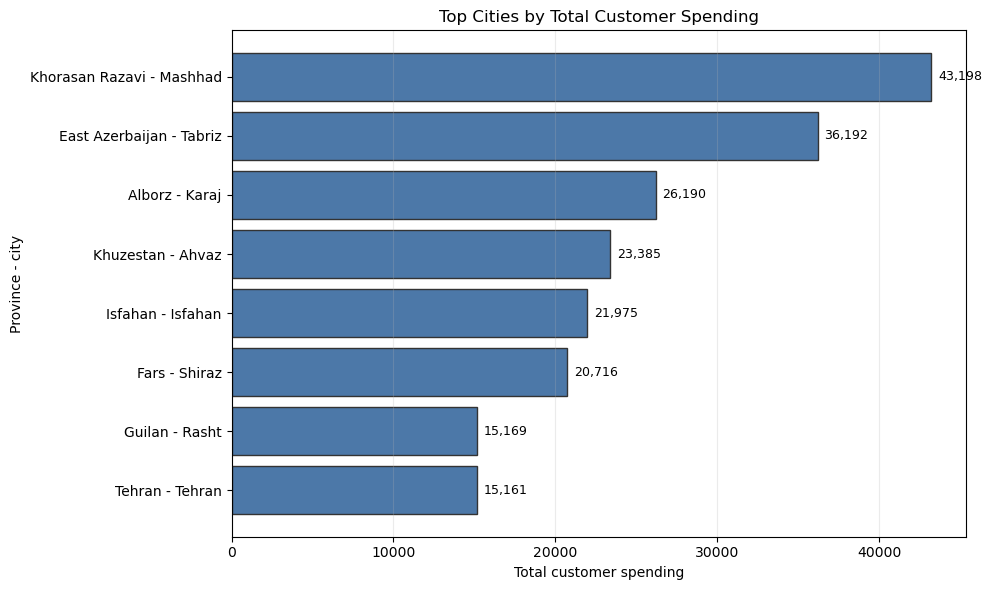

In [16]:
def plot_top_cities_by_revenue(
    city_summary: pd.DataFrame,
    top_n: int = 10,
) -> plt.Axes:
    """Plot the highest-value cities using a horizontal bar chart.

    Args:
        city_summary: City-level metrics.
        top_n: Maximum number of cities to display.

    Returns:
        The Matplotlib axes containing the chart.
    """
    if top_n < 1:
        raise ValueError("top_n must be at least 1.")

    chart_data = city_summary.nlargest(top_n, "total_revenue").sort_values("total_revenue")
    labels = chart_data["province"] + " - " + chart_data["city"]

    fig, ax = plt.subplots(figsize=(10, 6))
    bars = ax.barh(labels, chart_data["total_revenue"], color="#4C78A8", edgecolor="#333333")
    for bar, value in zip(bars, chart_data["total_revenue"]):
        ax.annotate(
            f"{value:,.0f}",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
        )
    ax.set_title("Top Cities by Total Customer Spending")
    ax.set_xlabel("Total customer spending")
    ax.set_ylabel("Province - city")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


top_city_chart = plot_top_cities_by_revenue(city_summary)

### 6. Financial Value Versus Customer Satisfaction

The scatter plot compares total customer spending with average satisfaction. Point size is proportional to the number of unique customers, so the chart shows market scale, financial value, and satisfaction in one view. The annotated markets make the recommended and alternative options easier to compare.

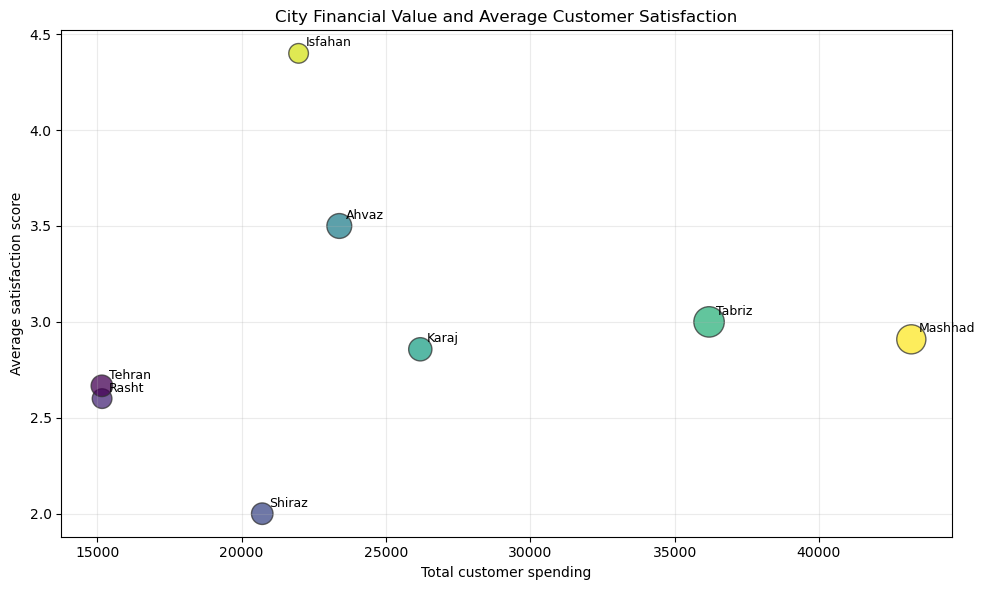

In [17]:
def plot_city_value_vs_satisfaction(
    scored_city_summary: pd.DataFrame,
    point_size_multiplier: int = 40,
) -> plt.Axes:
    """Plot city financial value against average satisfaction.

    Args:
        scored_city_summary: City-level table with customer counts and priority scores.
        point_size_multiplier: Multiplier used to scale point area by customer count.

    Returns:
        The Matplotlib axes containing the scatter plot.
    """
    if point_size_multiplier <= 0:
        raise ValueError("point_size_multiplier must be positive.")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(
        scored_city_summary["total_revenue"],
        scored_city_summary["avg_satisfaction"],
        s=scored_city_summary["customer_count"] * point_size_multiplier,
        c=scored_city_summary["priority_score"],
        cmap="viridis",
        alpha=0.75,
        edgecolors="#333333",
    )
    for _, row in scored_city_summary.iterrows():
        ax.annotate(
            row["city"],
            (row["total_revenue"], row["avg_satisfaction"]),
            xytext=(5, 5),
            textcoords="offset points",
            fontsize=9,
        )
    ax.set_title("City Financial Value and Average Customer Satisfaction")
    ax.set_xlabel("Total customer spending")
    ax.set_ylabel("Average satisfaction score")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


value_satisfaction_chart = plot_city_value_vs_satisfaction(scored_city_summary)

### 7. Interpretation and Final Recommendation

The final recommendation must consider at least three indicators: total customer spending, average customer spending, and average satisfaction. A city with high total spending but weak satisfaction may offer scale while also carrying a customer-experience risk. A city with high satisfaction and per-customer value but few customers may be attractive for a smaller pilot, but its averages are less stable.

In [18]:
def build_location_recommendation(
    primary: pd.DataFrame,
    alternative: pd.DataFrame,
) -> str:
    """Create an evidence-based narrative for the location decision.

    Args:
        primary: One-row table containing the recommended market.
        alternative: One-row table containing the alternative market.

    Returns:
        An English paragraph that explains the recommendation, benefit, and risk.

    Raises:
        ValueError: If either recommendation table is empty.
    """
    if primary.empty or alternative.empty:
        raise ValueError("Both a primary and an alternative market are required.")

    main = primary.iloc[0]
    backup = alternative.iloc[0]
    return (
        f"The primary advertising recommendation is {main['city']} in {main['province']}. It has "
        f"{int(main['customer_count'])} customers and the highest total customer spending at "
        f"{main['total_revenue']:,.2f}. Its average customer spending is {main['avg_customer_spending']:,.2f}, "
        f"and its average satisfaction score is {main['avg_satisfaction']:.2f}. This combination provides the "
        f"broadest observed financial reach while retaining strong per-customer value. The recommended "
        f"alternative is {backup['city']} in {backup['province']}: it has the highest average customer spending "
        f"({backup['avg_customer_spending']:,.2f}) and the highest satisfaction ({backup['avg_satisfaction']:.2f}), "
        f"but only {int(backup['customer_count'])} customers and lower total spending ({backup['total_revenue']:,.2f}), "
        f"so it is better suited to a smaller pilot. The main risk in {main['city']} is that its satisfaction "
        f"score is below the alternative; campaign performance should therefore be monitored with satisfaction "
        f"and response KPIs. These are descriptive patterns in the cleaned customer data, not proof that "
        f"advertising investment caused the observed spending or satisfaction."
    )


location_recommendation = build_location_recommendation(
    recommended_city, alternative_city
)
print(location_recommendation)

The primary advertising recommendation is Mashhad in Khorasan Razavi. It has 11 customers and the highest total customer spending at 43,197.58. Its average customer spending is 3,927.05, and its average satisfaction score is 2.91. This combination provides the broadest observed financial reach while retaining strong per-customer value. The recommended alternative is Isfahan in Isfahan: it has the highest average customer spending (4,395.06) and the highest satisfaction (4.40), but only 5 customers and lower total spending (21,975.32), so it is better suited to a smaller pilot. The main risk in Mashhad is that its satisfaction score is below the alternative; campaign performance should therefore be monitored with satisfaction and response KPIs. These are descriptive patterns in the cleaned customer data, not proof that advertising investment caused the observed spending or satisfaction.


### 8. Final Answer for Question 2

Based on the cleaned data and the stated decision weights, prioritize **Mashhad, Khorasan Razavi** for the first advertising investment. It has the highest total customer spending, a large customer base, and strong average customer spending. Treat **Isfahan, Isfahan province** as the alternative pilot market because it has the highest average customer spending and satisfaction, while recognizing that its smaller customer base makes the estimates less stable. The main campaign risk in Mashhad is its lower satisfaction than Isfahan, so satisfaction should be monitored alongside financial return.


## Question 3 - Customers to Prioritize for the Loyalty Program

**Business question:** Which customers should receive priority for the loyalty program?

Management can select only 10 customers. The selected customers should combine high financial value, frequent purchasing, recent activity, and positive satisfaction. Membership tier is reported for context, but it is not used as a selection rule because tier alone does not demonstrate customer value or current engagement.

This section uses a transparent weighted score. It is a prioritization method for the available customer snapshot, not a prediction of future loyalty or a causal claim.

### 1. Prepare the Loyalty Analysis Data

Only customers with complete information for the required fields are included. The analysis keeps `membership_tier` in the output table so that management can compare the computed loyalty priority with the current tier assignment.

In [19]:
LOYALTY_COLUMNS = [
    "customer_id",
    "first_name",
    "membership_tier",
    "purchase_count",
    "total_spending",
    "last_purchase_days",
    "satisfaction_score",
]


def prepare_loyalty_analysis_data(
    df: pd.DataFrame,
    required_columns: list[str] = LOYALTY_COLUMNS,
) -> pd.DataFrame:
    """Return complete customer records required for loyalty prioritization.

    Args:
        df: Cleaned customer-level dataset.
        required_columns: Columns required to calculate and report the loyalty score.

    Returns:
        A copy containing customers with complete loyalty-analysis fields.

    Raises:
        ValueError: If a required column is missing or no complete rows remain.
    """
    missing_columns = sorted(set(required_columns) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing required loyalty-analysis columns: {missing_columns}")

    loyalty_df = df.dropna(subset=required_columns).copy()
    if loyalty_df.empty:
        raise ValueError("No complete rows are available for loyalty analysis.")
    return loyalty_df


loyalty_df = prepare_loyalty_analysis_data(customer_df)
loyalty_preparation_summary = pd.DataFrame(
    {
        "metric": [
            "input_customers",
            "customers_used_for_question_3",
            "customers_excluded_due_to_missing_values",
        ],
        "value": [
            customer_df["customer_id"].nunique(),
            loyalty_df["customer_id"].nunique(),
            customer_df["customer_id"].nunique() - loyalty_df["customer_id"].nunique(),
        ],
    }
)
display(loyalty_preparation_summary)

,metric,value
0,input_customers,60
1,customers_used_for_question_3,60
2,customers_excluded_due_to_missing_values,0


### 2. Calculate the Weighted Loyalty Score

The underlying measures use different scales, so min-max normalization converts each measure to a 0-1 range before combining them. Higher values are better for spending, purchase count, and satisfaction. For `last_purchase_days`, fewer days means a more recent purchase, so the normalized value is inverted.

The documented weighting assumption is: 35% total spending, 30% purchase count, 20% purchase recency, and 15% satisfaction. Financial value and repeat behavior receive the largest weights because the program is intended for valuable, repeatedly purchasing customers; recency and satisfaction confirm that they remain active and receptive.

In [20]:
LOYALTY_WEIGHTS = {
    "total_spending": 0.35,
    "purchase_count": 0.30,
    "recency": 0.20,
    "satisfaction_score": 0.15,
}


def min_max_normalize(series: pd.Series, invert: bool = False) -> pd.Series:
    """Normalize a numeric series to a 0-1 range.

    Args:
        series: Numeric values to normalize.
        invert: Whether lower original values should receive higher normalized scores.

    Returns:
        A 0-1 score series, with equal values assigned a score of 1.0.
    """
    minimum = series.min()
    maximum = series.max()
    if maximum == minimum:
        return pd.Series(1.0, index=series.index, dtype=float)

    normalized = (series - minimum) / (maximum - minimum)
    return 1 - normalized if invert else normalized


def calculate_loyalty_scores(
    loyalty_df: pd.DataFrame,
    weights: dict[str, float] = LOYALTY_WEIGHTS,
) -> pd.DataFrame:
    """Add normalized measures and a weighted loyalty score for each customer.

    Args:
        loyalty_df: Complete customer records prepared for loyalty analysis.
        weights: Weights for financial value, frequency, recency, and satisfaction.

    Returns:
        A copy of loyalty_df with component scores and loyalty_score.

    Raises:
        ValueError: If weights are negative or do not have a positive total.
    """
    if any(weight < 0 for weight in weights.values()) or sum(weights.values()) <= 0:
        raise ValueError("Weights must be non-negative and have a positive total.")

    scored_df = loyalty_df.copy()
    scored_df["total_spending_score"] = min_max_normalize(scored_df["total_spending"])
    scored_df["purchase_count_score"] = min_max_normalize(scored_df["purchase_count"])
    scored_df["recency_score"] = min_max_normalize(
        scored_df["last_purchase_days"], invert=True
    )
    scored_df["satisfaction_score_score"] = min_max_normalize(
        scored_df["satisfaction_score"]
    )

    weight_total = sum(weights.values())
    scored_df["loyalty_score"] = (
        weights["total_spending"] / weight_total * scored_df["total_spending_score"]
        + weights["purchase_count"] / weight_total * scored_df["purchase_count_score"]
        + weights["recency"] / weight_total * scored_df["recency_score"]
        + weights["satisfaction_score"] / weight_total * scored_df["satisfaction_score_score"]
    )
    return scored_df


loyalty_scored_df = calculate_loyalty_scores(loyalty_df)
display(
    loyalty_scored_df[
        [
            "customer_id",
            "total_spending_score",
            "purchase_count_score",
            "recency_score",
            "satisfaction_score_score",
            "loyalty_score",
        ]
    ].head().round(3)
)

,customer_id,total_spending_score,purchase_count_score,recency_score,satisfaction_score_score,loyalty_score
0,1001,0.144,0.486,0.964,1.00,0.539
1,1002,0.273,0.343,1.000,0.50,0.473
2,1003,0.087,0.600,0.948,0.00,0.400
3,1004,0.426,0.657,0.898,0.75,0.638
4,1005,0.272,0.657,0.254,0.75,0.456


### 3. Select the Ten Highest-Priority Customers

The table below ranks the 10 customers with the highest weighted loyalty score. `selection_reason` identifies the strongest weighted component of each selected customer's score, providing an auditable reason for inclusion rather than relying only on membership tier.

In [21]:
def build_selection_reason(row: pd.Series) -> str:
    """Return the strongest weighted reason for a customer's loyalty selection.

    Args:
        row: One customer row containing loyalty-score components.

    Returns:
        A concise English explanation of the customer's strongest score driver.
    """
    weighted_components = {
        "High total spending": LOYALTY_WEIGHTS["total_spending"] * row["total_spending_score"],
        "Frequent purchasing": LOYALTY_WEIGHTS["purchase_count"] * row["purchase_count_score"],
        "Recent purchase activity": LOYALTY_WEIGHTS["recency"] * row["recency_score"],
        "High satisfaction": LOYALTY_WEIGHTS["satisfaction_score"] * row["satisfaction_score_score"],
    }
    primary_reason = max(weighted_components, key=weighted_components.get)

    if primary_reason == "High total spending":
        return f"High total spending ({row['total_spending']:,.2f})"
    if primary_reason == "Frequent purchasing":
        return f"Frequent purchasing ({int(row['purchase_count'])} purchases)"
    if primary_reason == "Recent purchase activity":
        return f"Recent purchase activity ({int(row['last_purchase_days'])} days ago)"
    return f"High satisfaction ({row['satisfaction_score']:.0f}/5)"


def select_top_loyal_customers(
    loyalty_scored_df: pd.DataFrame,
    top_n: int = 10,
) -> pd.DataFrame:
    """Return the highest-scoring customers with an evidence-based selection reason.

    Args:
        loyalty_scored_df: Customer-level table containing loyalty_score.
        top_n: Number of customers to select for the loyalty program.

    Returns:
        A ranked table of selected customers and their primary selection reason.

    Raises:
        ValueError: If top_n is invalid or loyalty_score is missing.
    """
    if top_n < 1:
        raise ValueError("top_n must be at least 1.")
    if "loyalty_score" not in loyalty_scored_df.columns:
        raise ValueError("loyalty_score is required before selecting customers.")

    top_customers = loyalty_scored_df.nlargest(top_n, "loyalty_score").copy()
    top_customers["selection_reason"] = top_customers.apply(build_selection_reason, axis=1)

    output_columns = [
        "customer_id",
        "first_name",
        "membership_tier",
        "purchase_count",
        "total_spending",
        "last_purchase_days",
        "satisfaction_score",
        "loyalty_score",
        "selection_reason",
    ]
    return top_customers[output_columns].reset_index(drop=True)


top_loyal_customers = select_top_loyal_customers(loyalty_scored_df)
display(top_loyal_customers.round({"total_spending": 2, "loyalty_score": 3}))

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,loyalty_score,selection_reason
0,1057,Maryam,Bronze,31,13532.74,82,4,0.865,"High total spending (13,532.74)"
1,1044,Mina,Gold,33,14354.34,165,2,0.781,"High total spending (14,354.34)"
2,1059,Ali,Gold,31,8898.55,224,5,0.711,Frequent purchasing (31 purchases)
3,1009,Kimia,Silver,34,11615.42,232,2,0.686,Frequent purchasing (34 purchases)
4,1004,Sina,Gold,23,6121.45,40,4,0.638,Frequent purchasing (23 purchases)
5,1012,Arash,Gold,27,11731.50,224,2,0.633,"High total spending (11,731.50)"
6,1033,Neda,VIP,24,5521.20,112,5,0.630,Frequent purchasing (24 purchases)
7,1014,Reza,VIP,31,3353.89,97,4,0.608,Frequent purchasing (31 purchases)
8,1023,Ali,Bronze,31,3851.44,170,4,0.580,Frequent purchasing (31 purchases)
9,1017,Parsa,VIP,30,3239.40,135,4,0.576,Frequent purchasing (30 purchases)


### 4. Purchase Frequency and Financial Value

This scatter plot places purchase frequency on the horizontal axis and total customer spending on the vertical axis. The point size represents purchase recency, so larger points indicate more recently active customers. The selected customers are highlighted with star markers to show how the combined score balances financial value, repeat purchases, recency, and satisfaction.

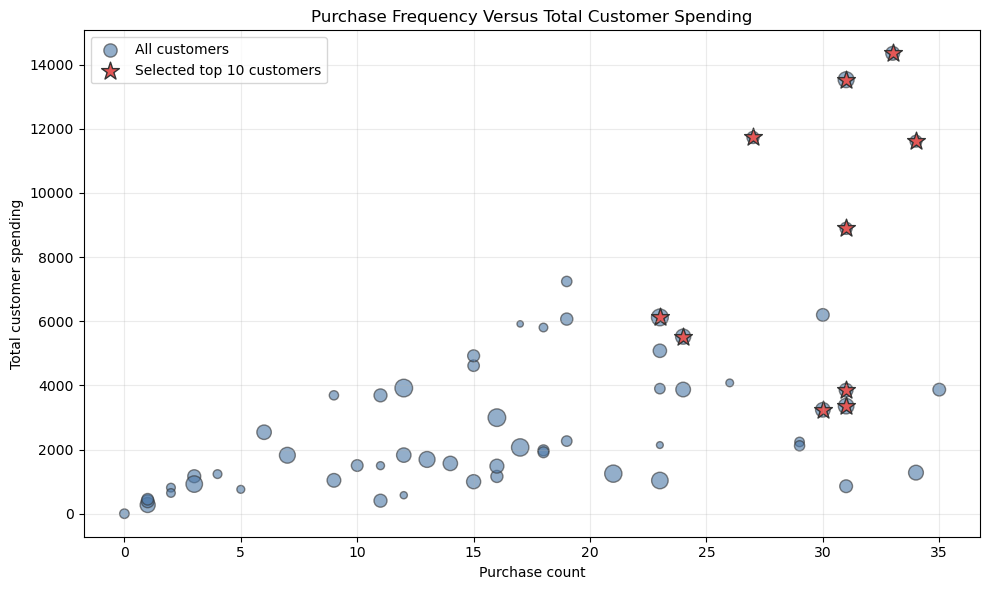

In [22]:
def plot_loyalty_priority_scatter(
    loyalty_scored_df: pd.DataFrame,
    top_loyal_customers: pd.DataFrame,
    point_size_multiplier: int = 140,
) -> plt.Axes:
    """Plot purchase frequency versus spending and highlight loyalty selections.

    Args:
        loyalty_scored_df: All scored customers.
        top_loyal_customers: Selected high-priority customers.
        point_size_multiplier: Multiplier used to scale point area by recency.

    Returns:
        The Matplotlib axes containing the loyalty-priority scatter plot.
    """
    if point_size_multiplier <= 0:
        raise ValueError("point_size_multiplier must be positive.")

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(
        loyalty_scored_df["purchase_count"],
        loyalty_scored_df["total_spending"],
        s=(loyalty_scored_df["recency_score"] + 0.15) * point_size_multiplier,
        alpha=0.60,
        color="#4C78A8",
        edgecolors="#333333",
        label="All customers",
    )
    ax.scatter(
        top_loyal_customers["purchase_count"],
        top_loyal_customers["total_spending"],
        s=180,
        marker="*",
        color="#E45756",
        edgecolors="#333333",
        label="Selected top 10 customers",
    )
    ax.set_title("Purchase Frequency Versus Total Customer Spending")
    ax.set_xlabel("Purchase count")
    ax.set_ylabel("Total customer spending")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


loyalty_scatter = plot_loyalty_priority_scatter(
    loyalty_scored_df, top_loyal_customers
)

### 5. Interpretation and Final Recommendation

The selected customers should not be assumed to be loyal only because of their membership tier. The score highlights customers who contribute strong financial value or repeat activity while also accounting for recent purchasing and satisfaction. Customers with high spending but less recent activity can still rank highly because financial value has the largest weight; this is a deliberate trade-off that should be reviewed before issuing rewards.

In [23]:
def build_loyalty_recommendation(top_loyal_customers: pd.DataFrame) -> str:
    """Create a concise management recommendation from the top loyalty customers.

    Args:
        top_loyal_customers: Ranked table of customers selected for the loyalty program.

    Returns:
        An English paragraph summarizing the selection and its main caveat.

    Raises:
        ValueError: If the selection table is empty.
    """
    if top_loyal_customers.empty:
        raise ValueError("At least one selected customer is required.")

    leading_customer = top_loyal_customers.iloc[0]
    tier_counts = top_loyal_customers["membership_tier"].value_counts().to_dict()
    average_recency = top_loyal_customers["last_purchase_days"].mean()
    return (
        f"The loyalty program should initially prioritize the 10 customers in the ranked table. "
        f"The leading customer is {leading_customer['first_name']} (ID {int(leading_customer['customer_id'])}) "
        f"with a loyalty score of {leading_customer['loyalty_score']:.3f}, based primarily on "
        f"{leading_customer['selection_reason'].lower()}. The selected group spans membership tiers "
        f"{tier_counts}, confirming that tier alone would not have identified the same priority list. "
        f"Their average time since last purchase is {average_recency:.1f} days. Some selected customers "
        f"have high historical spending but are not the most recent purchasers, so the program should "
        f"use a tailored re-engagement message for those cases rather than assuming all selected customers "
        f"are equally active today. This score is descriptive and should be refreshed when new customer "
        f"activity becomes available."
    )


loyalty_recommendation = build_loyalty_recommendation(top_loyal_customers)
print(loyalty_recommendation)

The loyalty program should initially prioritize the 10 customers in the ranked table. The leading customer is Maryam (ID 1057) with a loyalty score of 0.865, based primarily on high total spending (13,532.74). The selected group spans membership tiers {'Gold': 4, 'VIP': 3, 'Bronze': 2, 'Silver': 1}, confirming that tier alone would not have identified the same priority list. Their average time since last purchase is 148.1 days. Some selected customers have high historical spending but are not the most recent purchasers, so the program should use a tailored re-engagement message for those cases rather than assuming all selected customers are equally active today. This score is descriptive and should be refreshed when new customer activity becomes available.


### 6. Final Answer for Question 3

Prioritize the 10 customers listed in the loyalty table rather than selecting customers only by membership tier. The combined score gives the greatest importance to total spending and purchase frequency, then confirms recent activity and satisfaction. The leading customer is Maryam (ID 1057), whose strong spending and frequent purchases are supported by recent activity and good satisfaction. Customers with high spending but older purchases remain in the selection when their financial value is sufficiently strong; these customers should receive a re-engagement-oriented loyalty offer and their response should be monitored.


## Question 4 - High-Value Customers at Risk of Inactivity

**Business question:** Which high-value customers are at risk of becoming inactive?

This section identifies customers who have created high value for the store, purchase at least as often as a typical customer, and have not purchased recently. The purpose is to prioritize retention outreach before these valuable customers are lost. This is an observed-risk flag, not proof of future churn, because the dataset contains only the time since the latest purchase rather than complete order history.

### 1. Prepare Data and Apply the At-Risk Rule

A customer is flagged only when all three conditions are true: total spending is at or above the 75th percentile, purchase count is at or above the median, and days since the latest purchase is at or above the 75th percentile. This prevents low-value inactive customers from being treated as the highest retention priority. Membership tier and satisfaction are retained for reporting and campaign design.

In [24]:
RISK_COLUMNS = [
    "customer_id", "first_name", "membership_tier", "total_spending",
    "purchase_count", "last_purchase_days", "satisfaction_score",
]


def prepare_at_risk_analysis_data(df: pd.DataFrame) -> pd.DataFrame:
    """Return complete customer records required for inactivity-risk analysis.

    Args:
        df: Cleaned customer-level dataset.

    Returns:
        A copy containing customers with complete at-risk analysis fields.

    Raises:
        ValueError: If a required column is missing or no complete rows remain.
    """
    missing_columns = sorted(set(RISK_COLUMNS) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing required at-risk analysis columns: {missing_columns}")
    prepared_df = df.dropna(subset=RISK_COLUMNS).copy()
    if prepared_df.empty:
        raise ValueError("No complete rows are available for at-risk analysis.")
    return prepared_df


def calculate_at_risk_thresholds(risk_df: pd.DataFrame) -> dict[str, float]:
    """Calculate transparent value, frequency, and inactivity thresholds.

    Args:
        risk_df: Complete customer records prepared for at-risk analysis.

    Returns:
        Thresholds based on the 75th percentile or median of the observed data.
    """
    return {
        "spending_threshold": float(risk_df["total_spending"].quantile(0.75)),
        "purchase_threshold": float(risk_df["purchase_count"].median()),
        "inactivity_threshold": float(risk_df["last_purchase_days"].quantile(0.75)),
    }


def flag_at_risk_customers(risk_df: pd.DataFrame, thresholds: dict[str, float]) -> pd.DataFrame:
    """Flag customers who meet the value, frequency, and inactivity conditions together.

    Args:
        risk_df: Complete customer records prepared for at-risk analysis.
        thresholds: Value, frequency, and inactivity thresholds.

    Returns:
        A copy of risk_df with a Boolean at_risk column.
    """
    expected = {"spending_threshold", "purchase_threshold", "inactivity_threshold"}
    missing_thresholds = sorted(expected - set(thresholds))
    if missing_thresholds:
        raise ValueError(f"Missing threshold values: {missing_thresholds}")
    flagged_df = risk_df.copy()
    flagged_df["at_risk"] = (
        (flagged_df["total_spending"] >= thresholds["spending_threshold"])
        & (flagged_df["purchase_count"] >= thresholds["purchase_threshold"])
        & (flagged_df["last_purchase_days"] >= thresholds["inactivity_threshold"])
    )
    return flagged_df


risk_df = prepare_at_risk_analysis_data(customer_df)
risk_thresholds = calculate_at_risk_thresholds(risk_df)
risk_df = flag_at_risk_customers(risk_df, risk_thresholds)

threshold_table = pd.DataFrame({
    "metric": [
        "High-value spending threshold (75th percentile)",
        "Purchase-frequency threshold (median)",
        "Inactivity threshold (75th percentile)",
    ],
    "value": [
        risk_thresholds["spending_threshold"],
        risk_thresholds["purchase_threshold"],
        risk_thresholds["inactivity_threshold"],
    ],
})
display(threshold_table.round(2))

,metric,value
0,High-value spending threshold (75th percentile),4213.12
1,Purchase-frequency threshold (median),17.00
2,Inactivity threshold (75th percentile),273.75


### 2. Build the Retention Target List

The target list is sorted by total spending and then by days since last purchase, so the most valuable and most inactive customers are reviewed first. Satisfaction changes the proposed action: scores 1-2 receive service recovery before an incentive, score 3 receives a focused re-engagement reminder, and scores 4-5 receive a personalized loyalty offer.

In [25]:
def recommend_retention_action(satisfaction_score: float) -> str:
    """Return a retention action tailored to the satisfaction score.

    Args:
        satisfaction_score: Customer satisfaction score on the available 1-5 scale.

    Returns:
        A concise recommended retention action.
    """
    if satisfaction_score <= 2:
        return "Service recovery: request feedback and resolve the experience issue first"
    if satisfaction_score >= 4:
        return "Personalized loyalty incentive: reward an already satisfied customer"
    return "Focused re-engagement: send a reminder with a limited-time offer"


def build_at_risk_customer_list(risk_df: pd.DataFrame) -> pd.DataFrame:
    """Return a prioritized retention list for customers flagged as at risk.

    Args:
        risk_df: Customer table containing the Boolean at_risk flag.

    Returns:
        A sorted table of at-risk customers with suggested retention actions.
    """
    if "at_risk" not in risk_df.columns:
        raise ValueError("The at_risk flag must be calculated before building the target list.")
    output_columns = [
        "customer_id", "first_name", "membership_tier", "purchase_count",
        "total_spending", "last_purchase_days", "satisfaction_score",
    ]
    target_list = risk_df.loc[risk_df["at_risk"], output_columns].copy()
    target_list["recommended_action"] = target_list["satisfaction_score"].apply(
        recommend_retention_action
    )
    return target_list.sort_values(
        ["total_spending", "last_purchase_days"], ascending=[False, False]
    ).reset_index(drop=True)


at_risk_customers = build_at_risk_customer_list(risk_df)
display(at_risk_customers.round({"total_spending": 2}))
print(f"At-risk customer count: {len(at_risk_customers)}")

,customer_id,first_name,membership_tier,purchase_count,total_spending,last_purchase_days,satisfaction_score,recommended_action
0,1010,Arash,Silver,19,7241.47,276,1,Service recovery: request feedback and resolve...
1,1035,Arash,Bronze,17,5918.21,365,3,Focused re-engagement: send a reminder with a ...
2,1053,Sina,Gold,18,5805.54,320,1,Service recovery: request feedback and resolve...


At-risk customer count: 3


### 3. Value and Inactivity Risk Map

The scatter plot compares days since the latest purchase with total customer spending. The dashed lines make the decision thresholds visible. Customers shown with X markers meet all three conditions, including the purchase-frequency requirement, and are the immediate retention priorities.

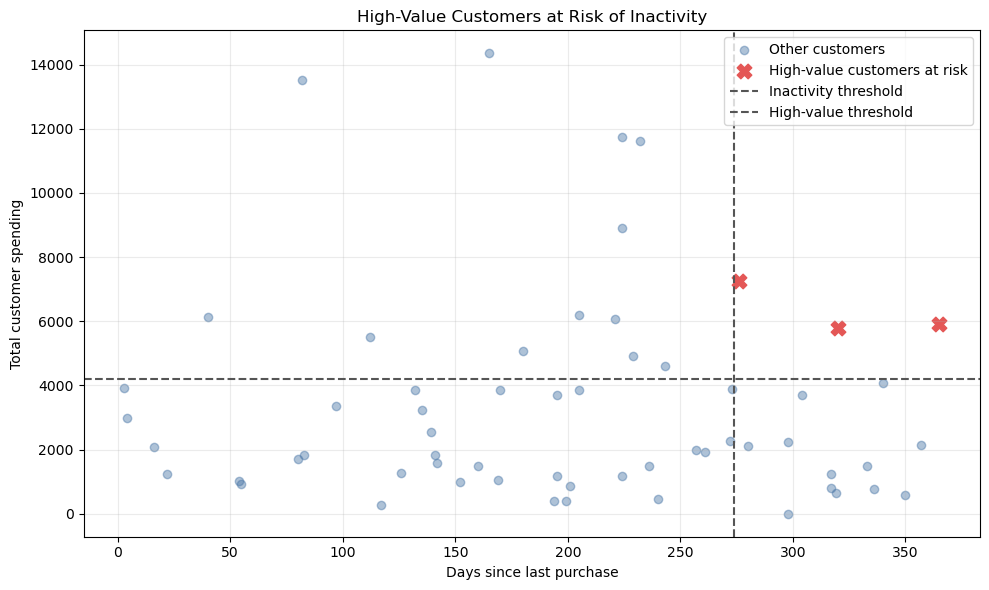

In [26]:
def plot_at_risk_customers(risk_df: pd.DataFrame, thresholds: dict[str, float]) -> plt.Axes:
    """Plot customer value versus inactivity and highlight at-risk customers.

    Args:
        risk_df: Customer table containing at_risk flags.
        thresholds: Value, frequency, and inactivity thresholds.

    Returns:
        The Matplotlib axes containing the at-risk customer chart.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(
        risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
        risk_df.loc[~risk_df["at_risk"], "total_spending"],
        alpha=0.45, color="#4C78A8", label="Other customers",
    )
    ax.scatter(
        risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
        risk_df.loc[risk_df["at_risk"], "total_spending"],
        marker="X", s=110, color="#E45756", label="High-value customers at risk",
    )
    ax.axvline(thresholds["inactivity_threshold"], linestyle="--", color="#555555", label="Inactivity threshold")
    ax.axhline(thresholds["spending_threshold"], linestyle="--", color="#555555", label="High-value threshold")
    ax.set_title("High-Value Customers at Risk of Inactivity")
    ax.set_xlabel("Days since last purchase")
    ax.set_ylabel("Total customer spending")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


at_risk_chart = plot_at_risk_customers(risk_df, risk_thresholds)

### 4. Interpretation and Final Recommendation

The at-risk target list has priority over lower-value inactive customers because its members have generated high historical value and purchased at least as frequently as the typical customer. A low satisfaction score suggests that an experience issue may be contributing to inactivity, so service recovery should happen before a discount. This flag should be refreshed when new purchase activity is available.

In [27]:
def build_at_risk_recommendation(at_risk_customers: pd.DataFrame, thresholds: dict[str, float]) -> str:
    """Create a concise retention recommendation from the at-risk target list.

    Args:
        at_risk_customers: Prioritized at-risk customer list.
        thresholds: Thresholds used to define the at-risk flag.

    Returns:
        An English paragraph explaining the target list and next actions.
    """
    if at_risk_customers.empty:
        return "No customer meets all three high-value, frequency, and inactivity conditions."
    low_satisfaction_count = int((at_risk_customers["satisfaction_score"] <= 2).sum())
    first_priority = at_risk_customers.iloc[0]
    return (
        f"The retention campaign should target {len(at_risk_customers)} customers who meet all three conditions: "
        f"total spending of at least {thresholds['spending_threshold']:,.2f}, at least "
        f"{thresholds['purchase_threshold']:.0f} purchases, and at least "
        f"{thresholds['inactivity_threshold']:.2f} days since the latest purchase. The first contact "
        f"priority is {first_priority['first_name']} (ID {int(first_priority['customer_id'])}) because this "
        f"customer has the highest total spending in the target list ({first_priority['total_spending']:,.2f}). "
        f"{low_satisfaction_count} targeted customer(s) have low satisfaction and should receive service recovery "
        f"before a discount. This is an observed-risk flag, not proof that the customers will churn."
    )


at_risk_recommendation = build_at_risk_recommendation(at_risk_customers, risk_thresholds)
print(at_risk_recommendation)

The retention campaign should target 3 customers who meet all three conditions: total spending of at least 4,213.12, at least 17 purchases, and at least 273.75 days since the latest purchase. The first contact priority is Arash (ID 1010) because this customer has the highest total spending in the target list (7,241.47). 2 targeted customer(s) have low satisfaction and should receive service recovery before a discount. This is an observed-risk flag, not proof that the customers will churn.


### 5. Final Answer for Question 4

Prioritize the customers listed in the at-risk target table for a retention campaign. They have high historical spending, purchase at least as often as the typical customer, and have been inactive for a comparatively long time. Customers with satisfaction scores of 1-2 should receive service recovery before any incentive, while neutral or satisfied inactive customers should receive a focused re-engagement offer. The available data identifies observed risk rather than proving future churn.

## Question 5 - Discount, Device, and Payment Method Behavior

**Business question:** What descriptive relationships do discount use, device, and payment method have with customer behavior?

Management wants to compare customers who used a discount with those who did not, and also understand whether customer value differs across devices and payment methods. The required metrics are `total_spending`, `purchase_count`, `avg_order_value`, `returned_items`, and `satisfaction_score`.

This section is deliberately **descriptive**. The data is observational and customer-level, so differences between groups must not be interpreted as proof that a discount, device, or payment method caused the observed behavior.

### 1. Prepare Complete Records for the Factor Analysis

The analysis starts from the same cleaned `customer_df` used by the earlier questions. The function below validates all required columns and removes rows only if one of the fields needed for Question 5 is missing. A preparation summary is displayed so the sample size used in the comparisons remains transparent.

In [28]:
FACTOR_COLUMNS = [
    "customer_id",
    "discount_used",
    "device",
    "payment_method",
    "total_spending",
    "purchase_count",
    "avg_order_value",
    "returned_items",
    "satisfaction_score",
]
MIN_CUSTOMERS_PER_FACTOR_GROUP = 3


def prepare_factor_analysis_data(
    df: pd.DataFrame,
    required_columns: list[str] = FACTOR_COLUMNS,
) -> pd.DataFrame:
    """Return complete customer records required for Question 5.

    Args:
        df: Cleaned customer-level dataset.
        required_columns: Columns required for the descriptive comparisons.

    Returns:
        A copy containing complete rows for all Question 5 variables.

    Raises:
        ValueError: If a required column is missing or no complete rows remain.
    """
    missing_columns = sorted(set(required_columns) - set(df.columns))
    if missing_columns:
        raise ValueError(f"Missing required factor-analysis columns: {missing_columns}")

    factor_df = df.dropna(subset=required_columns).copy()
    if factor_df.empty:
        raise ValueError("No complete rows are available for factor analysis.")
    return factor_df


factor_df = prepare_factor_analysis_data(customer_df)

factor_preparation_summary = pd.DataFrame(
    {
        "metric": [
            "input_rows",
            "complete_rows_used",
            "rows_excluded_due_to_missing_values",
            "unique_customers_used",
        ],
        "value": [
            len(customer_df),
            len(factor_df),
            len(customer_df) - len(factor_df),
            factor_df["customer_id"].nunique(),
        ],
    }
)
display(factor_preparation_summary)

,metric,value
0,input_rows,60
1,complete_rows_used,60
2,rows_excluded_due_to_missing_values,0
3,unique_customers_used,60


### 2. Build Comparable Summary Tables

A reusable aggregation function keeps the calculation method identical for discount use, device, and payment method. In addition to the required averages, the tables include **customer count** to show sample size and **median total spending** as a robustness check. The median is useful because Phase 1 intentionally preserved valid high-spending customers, which can pull group means upward.

Groups with fewer than three customers are excluded from the main comparison, matching the project's caution against interpreting very small samples.

In [29]:
def build_factor_summary(
    df: pd.DataFrame,
    factor: str,
    minimum_customers: int = MIN_CUSTOMERS_PER_FACTOR_GROUP,
) -> pd.DataFrame:
    """Aggregate customer behavior metrics for one categorical factor.

    Args:
        df: Complete Question 5 customer records.
        factor: Categorical column used to define comparison groups.
        minimum_customers: Minimum unique customers required to retain a group.

    Returns:
        A group-level table sorted by average total spending.

    Raises:
        ValueError: If the factor is missing, the threshold is invalid, or no group remains.
    """
    if factor not in df.columns:
        raise ValueError(f"Factor column is missing: {factor}")
    if minimum_customers < 1:
        raise ValueError("minimum_customers must be at least 1.")

    summary = (
        df.groupby(factor, as_index=False)
        .agg(
            customer_count=("customer_id", "nunique"),
            avg_total_spending=("total_spending", "mean"),
            median_total_spending=("total_spending", "median"),
            avg_purchase_count=("purchase_count", "mean"),
            avg_order_value=("avg_order_value", "mean"),
            avg_returned_items=("returned_items", "mean"),
            avg_satisfaction=("satisfaction_score", "mean"),
        )
    )
    summary = summary[summary["customer_count"] >= minimum_customers].copy()
    if summary.empty:
        raise ValueError(f"No {factor} group meets the minimum customer threshold.")

    return summary.sort_values("avg_total_spending", ascending=False).reset_index(drop=True)


discount_summary = build_factor_summary(factor_df, "discount_used")
device_summary = build_factor_summary(factor_df, "device")
payment_summary = build_factor_summary(factor_df, "payment_method")

print("Discount comparison")
display(discount_summary.round(2))
print("Device comparison")
display(device_summary.round(2))
print("Payment-method comparison")
display(payment_summary.round(2))

Discount comparison


,discount_used,customer_count,avg_total_spending,median_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,No,34,3736.74,2751.72,17.29,220.70,3.97,2.76
1,Yes,26,2882.17,1945.17,17.50,203.29,3.58,3.27


Device comparison


,device,customer_count,avg_total_spending,median_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,iPhone,18,3773.94,1964.46,18.28,204.66,3.06,2.94
1,Android,22,3459.07,2190.52,17.91,209.79,4.45,3.09
2,Web,20,2897.76,2028.06,16.00,224.51,3.75,2.90


Payment-method comparison


,payment_method,customer_count,avg_total_spending,median_total_spending,avg_purchase_count,avg_order_value,avg_returned_items,avg_satisfaction
0,Card,18,3929.00,2808.96,18.78,224.14,4.11,3.28
1,Cash,19,3150.58,2237.35,19.21,192.26,4.00,3.47
2,Online Wallet,23,3104.46,1497.87,14.78,221.82,3.39,2.35


### 3. Quantify the Discount-Group Differences

The project specifically asks whether discount users spend more and whether they also return more items. The next table computes the direction and size of each observed difference using **discount users minus non-users**. A negative difference means the discount-user group has a lower observed average for that metric.

These differences are descriptive group contrasts only; they do not control for customer mix, campaign eligibility, timing, or other confounding variables.

In [30]:
DISCOUNT_METRICS = [
    "avg_total_spending",
    "avg_purchase_count",
    "avg_order_value",
    "avg_returned_items",
    "avg_satisfaction",
]


def build_discount_gap_table(discount_summary: pd.DataFrame) -> pd.DataFrame:
    """Compare discount users with non-users for the requested behavior metrics.

    Args:
        discount_summary: Summary table created for the discount_used factor.

    Returns:
        A metric-level table with group values and descriptive differences.

    Raises:
        ValueError: If either Yes or No discount group is unavailable.
    """
    indexed = discount_summary.set_index("discount_used")
    required_groups = {"Yes", "No"}
    if not required_groups.issubset(indexed.index):
        raise ValueError("Both 'Yes' and 'No' discount groups are required.")

    rows = []
    for metric in DISCOUNT_METRICS:
        without_discount = float(indexed.loc["No", metric])
        with_discount = float(indexed.loc["Yes", metric])
        absolute_difference = with_discount - without_discount
        percent_difference = (
            absolute_difference / without_discount * 100
            if without_discount != 0
            else float("nan")
        )
        rows.append(
            {
                "metric": metric,
                "without_discount": without_discount,
                "with_discount": with_discount,
                "difference_yes_minus_no": absolute_difference,
                "percent_difference_vs_no": percent_difference,
            }
        )
    return pd.DataFrame(rows)


discount_gap_table = build_discount_gap_table(discount_summary)
display(discount_gap_table.round(2))

,metric,without_discount,with_discount,difference_yes_minus_no,percent_difference_vs_no
0,avg_total_spending,3736.74,2882.17,-854.57,-22.87
1,avg_purchase_count,17.29,17.50,0.21,1.19
2,avg_order_value,220.70,203.29,-17.41,-7.89
3,avg_returned_items,3.97,3.58,-0.39,-9.91
4,avg_satisfaction,2.76,3.27,0.50,18.25


### 4. Discount Comparison Charts

The first chart compares average total customer spending for customers with and without a discount. The second compares average numbers of returned items. Customer counts are included in the x-axis labels so the size of each group is visible when reading the chart.

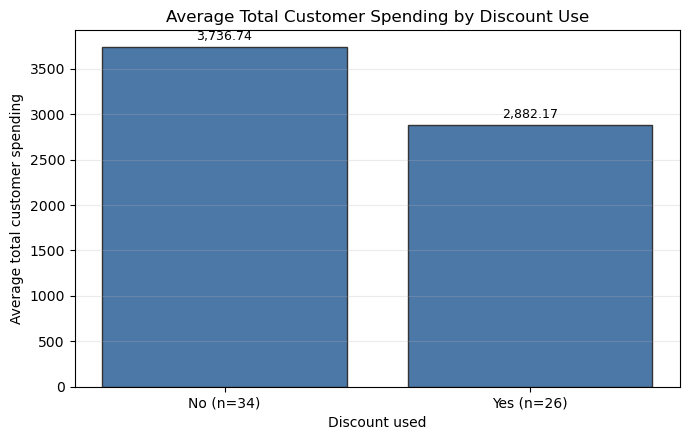

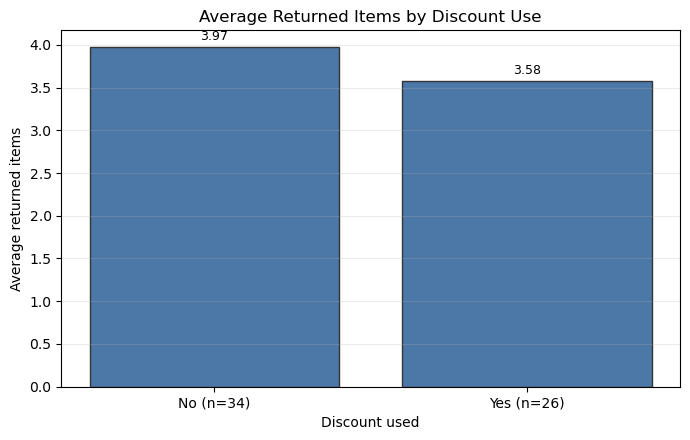

In [31]:
def plot_discount_metric(
    discount_summary: pd.DataFrame,
    metric: str,
    title: str,
    ylabel: str,
) -> plt.Axes:
    """Plot one average metric for discount users and non-users.

    Args:
        discount_summary: Discount-level summary table.
        metric: Numeric summary column to plot.
        title: Chart title.
        ylabel: Vertical-axis label.

    Returns:
        The Matplotlib axes containing the chart.
    """
    chart_data = discount_summary.sort_values("discount_used").copy()
    labels = [
        f"{group} (n={count})"
        for group, count in zip(chart_data["discount_used"], chart_data["customer_count"])
    ]

    fig, ax = plt.subplots(figsize=(7, 4.5))
    bars = ax.bar(labels, chart_data[metric], color="#4C78A8", edgecolor="#333333")
    for bar, value in zip(bars, chart_data[metric]):
        ax.annotate(
            f"{value:,.2f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 5),
            textcoords="offset points",
            ha="center",
            fontsize=9,
        )
    ax.set_title(title)
    ax.set_xlabel("Discount used")
    ax.set_ylabel(ylabel)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


discount_spending_chart = plot_discount_metric(
    discount_summary,
    "avg_total_spending",
    "Average Total Customer Spending by Discount Use",
    "Average total customer spending",
)

discount_returns_chart = plot_discount_metric(
    discount_summary,
    "avg_returned_items",
    "Average Returned Items by Discount Use",
    "Average returned items",
)

### 5. Device and Payment-Method Value Comparison

The next two charts rank device and payment-method groups by average total customer spending. Sample sizes are shown directly in the labels. The summary tables above should be read alongside the charts: if the mean and median tell different stories, the average may be influenced by a small number of high-value customers.

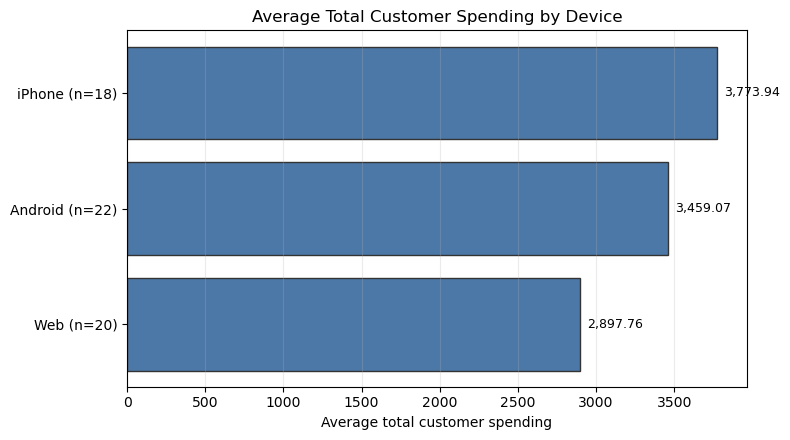

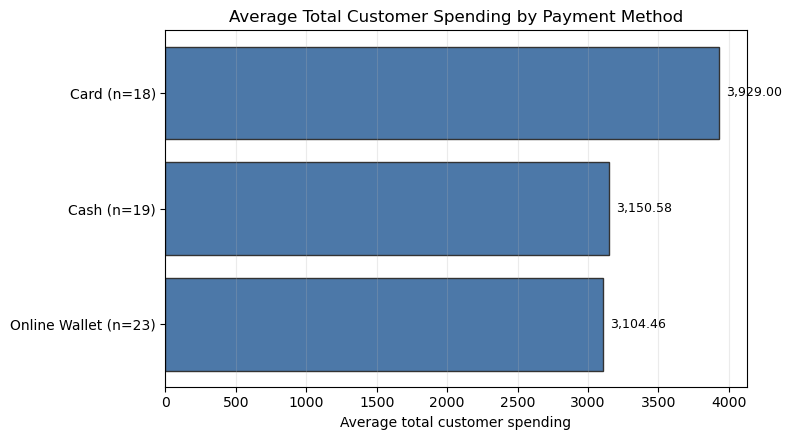

In [32]:
def plot_average_spending_by_factor(
    factor_summary: pd.DataFrame,
    factor: str,
    title: str,
) -> plt.Axes:
    """Plot average total spending for a device or payment-method summary.

    Args:
        factor_summary: Group-level summary created by build_factor_summary().
        factor: Group label column in the summary.
        title: Chart title.

    Returns:
        The Matplotlib axes containing the horizontal bar chart.
    """
    chart_data = factor_summary.sort_values("avg_total_spending").copy()
    labels = [
        f"{category} (n={count})"
        for category, count in zip(chart_data[factor], chart_data["customer_count"])
    ]

    fig, ax = plt.subplots(figsize=(8, 4.5))
    bars = ax.barh(
        labels,
        chart_data["avg_total_spending"],
        color="#4C78A8",
        edgecolor="#333333",
    )
    for bar, value in zip(bars, chart_data["avg_total_spending"]):
        ax.annotate(
            f"{value:,.2f}",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(5, 0),
            textcoords="offset points",
            va="center",
            fontsize=9,
        )
    ax.set_title(title)
    ax.set_xlabel("Average total customer spending")
    ax.set_ylabel("")
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()
    return ax


device_spending_chart = plot_average_spending_by_factor(
    device_summary,
    "device",
    "Average Total Customer Spending by Device",
)

payment_spending_chart = plot_average_spending_by_factor(
    payment_summary,
    "payment_method",
    "Average Total Customer Spending by Payment Method",
)

### 6. Interpretation and Management Recommendation

The descriptive evidence does **not** support the claim that discount users are the higher-spending group in this dataset. Their average purchase frequency is almost the same as the non-discount group, while their average total spending and average order value are lower. Their average number of returned items is also lower, not higher, and their average satisfaction is higher. This pattern should be treated as an observed association rather than a discount effect.

For device, iPhone has the highest **mean** total spending, but its median is lower than Android's median. That gap between mean and median is a warning that a small number of high-spending iPhone customers may be lifting the average. Therefore, device targeting should not be based on the mean alone.

For payment method, Card has the highest mean total spending and also the highest median total spending, making its value ranking more consistent than the device result. Cash has the highest average satisfaction and purchase frequency, while Online Wallet has the lowest average satisfaction in the observed sample.

All retained device and payment groups have at least 18 customers, so none of these comparisons is based on the project's very-small-sample case. However, the full dataset contains only 60 customers, so these findings are appropriate for descriptive prioritization and follow-up testing, not broad causal conclusions. Also, `returned_items` is a count rather than a true return rate because the dataset does not include the total number of individual items purchased.

In [33]:
def build_factor_behavior_recommendation(
    discount_summary: pd.DataFrame,
    device_summary: pd.DataFrame,
    payment_summary: pd.DataFrame,
) -> str:
    """Create a concise management recommendation for Question 5.

    Args:
        discount_summary: Summary by discount usage.
        device_summary: Summary by device.
        payment_summary: Summary by payment method.

    Returns:
        An English paragraph based on the observed descriptive metrics.
    """
    discount_indexed = discount_summary.set_index("discount_used")
    yes_group = discount_indexed.loc["Yes"]
    no_group = discount_indexed.loc["No"]
    top_device = device_summary.iloc[0]
    top_payment = payment_summary.iloc[0]

    spending_gap_percent = (
        (yes_group["avg_total_spending"] - no_group["avg_total_spending"])
        / no_group["avg_total_spending"]
        * 100
    )

    return (
        f"Discount users average {yes_group['avg_total_spending']:,.2f} in total spending versus "
        f"{no_group['avg_total_spending']:,.2f} for non-users ({spending_gap_percent:.1f}% relative difference). "
        f"They also average {yes_group['avg_returned_items']:.2f} returned items versus "
        f"{no_group['avg_returned_items']:.2f}, so this sample does not show higher returns among discount users. "
        f"The highest mean customer spending by device is {top_device['device']} "
        f"({top_device['avg_total_spending']:,.2f}, n={int(top_device['customer_count'])}), while the highest "
        f"mean by payment method is {top_payment['payment_method']} "
        f"({top_payment['avg_total_spending']:,.2f}, n={int(top_payment['customer_count'])}). "
        f"These are descriptive associations only and do not establish cause and effect."
    )


factor_behavior_recommendation = build_factor_behavior_recommendation(
    discount_summary,
    device_summary,
    payment_summary,
)
print(factor_behavior_recommendation)

Discount users average 2,882.17 in total spending versus 3,736.74 for non-users (-22.9% relative difference). They also average 3.58 returned items versus 3.97, so this sample does not show higher returns among discount users. The highest mean customer spending by device is iPhone (3,773.94, n=18), while the highest mean by payment method is Card (3,929.00, n=18). These are descriptive associations only and do not establish cause and effect.


### 7. Final Answer for Question 5

Customers who used a discount do **not** have higher observed average total spending in this dataset. The discount group contains 26 customers and averages about **2,882.17** in total spending, compared with **3,736.74** for 34 non-discount customers. Purchase frequency is nearly identical (**17.50** vs **17.29**), but discount users have a lower average order value (**203.29** vs **220.70**), fewer returned items on average (**3.58** vs **3.97**), and higher average satisfaction (**3.27** vs **2.76**). The median spending values point in the same direction as the means, so the lower spending of the discount group is not only a mean-based artifact.

By device, **iPhone** has the highest average total spending (**3,773.94**, n=18), followed by Android (**3,459.07**, n=22) and Web (**2,897.76**, n=20). However, Android has the highest median spending, so the iPhone mean should be interpreted cautiously because high-value customers appear to influence it.

By payment method, **Card** has the highest average total spending (**3,929.00**, n=18), followed by Cash (**3,150.58**, n=19) and Online Wallet (**3,104.46**, n=23). Card also has the highest median spending, which makes this ranking more consistent. Cash customers show the highest observed satisfaction and purchase frequency, while Online Wallet customers have the lowest average satisfaction.

**This analysis does not prove a cause-and-effect relationship.** Discount usage, device, and payment method are observed customer characteristics, and the dataset does not establish what caused the behavioral differences. The return metric is also a count of returned items, not a true return rate.

## Question 6 - Five-Minute Executive Management Report

**Business question:** What should the CEO understand and act on within five minutes?

The final section summarizes the entire customer analysis in one management view. It intentionally **reuses the validated outputs from Questions 1-5** instead of rebuilding the same logic from raw columns. The report is limited to **six KPIs**, **three charts**, and **three KPI → Action → Evidence recommendations** so the result stays decision-focused.

The selected charts represent three different management needs:

1. **Opportunity:** city-level customer value from Question 2.
2. **Risk:** high-value customers at risk of inactivity from Question 4.
3. **Commercial behavior:** average spending by discount use from Question 5.


### 1. Build the Six-KPI Executive Summary

The first five KPIs describe overall customer scale, value, purchasing activity, and satisfaction. The sixth KPI is the number of **high-value customers at risk of inactivity**, because Question 6 explicitly asks the report to surface the most important customer risk rather than only repeat descriptive totals.

The risk KPI uses the exact at-risk definition already established in Question 4, so the dashboard remains consistent with the earlier analysis.


In [34]:
def build_management_kpi_summary(
    df: pd.DataFrame,
    at_risk_customers: pd.DataFrame,
) -> pd.DataFrame:
    """Build the six KPIs used in the five-minute executive report.

    Args:
        df: Cleaned customer-level dataset.
        at_risk_customers: Question 4 target list of high-value inactive customers.

    Returns:
        A six-row management KPI table with numeric and presentation values.
    """
    unique_customers = int(df["customer_id"].nunique())
    at_risk_count = int(len(at_risk_customers))
    at_risk_share = at_risk_count / unique_customers if unique_customers else 0.0

    rows = [
        {
            "kpi": "Unique customers",
            "value": unique_customers,
            "display_value": f"{unique_customers:,}",
            "management_role": "Customer base size",
        },
        {
            "kpi": "Total customer spending",
            "value": float(df["total_spending"].sum()),
            "display_value": f"{df['total_spending'].sum():,.2f}",
            "management_role": "Observed customer value",
        },
        {
            "kpi": "Average total spending per customer",
            "value": float(df["total_spending"].mean()),
            "display_value": f"{df['total_spending'].mean():,.2f}",
            "management_role": "Average customer value",
        },
        {
            "kpi": "Average purchase count",
            "value": float(df["purchase_count"].mean()),
            "display_value": f"{df['purchase_count'].mean():.2f}",
            "management_role": "Purchase frequency",
        },
        {
            "kpi": "Average satisfaction",
            "value": float(df["satisfaction_score"].mean()),
            "display_value": f"{df['satisfaction_score'].mean():.2f} / 5",
            "management_role": "Customer experience",
        },
        {
            "kpi": "High-value customers at risk",
            "value": at_risk_count,
            "display_value": f"{at_risk_count} ({at_risk_share:.1%})",
            "management_role": "Immediate retention risk",
        },
    ]
    return pd.DataFrame(rows)


management_kpi_summary = build_management_kpi_summary(customer_df, at_risk_customers)
display(management_kpi_summary[["kpi", "display_value", "management_role"]])


,kpi,display_value,management_role
0,Unique customers,60,Customer base size
1,Total customer spending,"201,985.73",Observed customer value
2,Average total spending per customer,"3,366.43",Average customer value
3,Average purchase count,17.38,Purchase frequency
4,Average satisfaction,2.98 / 5,Customer experience
5,High-value customers at risk,3 (5.0%),Immediate retention risk


### 2. Build Three KPI → Action → Evidence Recommendations

A management report should not stop at describing metrics. The next table converts the strongest findings from the earlier questions into specific actions. Each row keeps the requested **KPI → Action → Evidence** structure and points back to the analysis that produced the evidence.

The three recommendations cover the most important advertising opportunity, the most urgent retention risk, and the main decision implication from the discount comparison.


In [35]:
def build_management_recommendations(
    scored_city_summary: pd.DataFrame,
    at_risk_customers: pd.DataFrame,
    risk_thresholds: dict[str, float],
    discount_summary: pd.DataFrame,
) -> pd.DataFrame:
    """Convert the strongest findings into three executive recommendations.

    Args:
        scored_city_summary: Question 2 city table with priority scores.
        at_risk_customers: Question 4 high-value at-risk customer list.
        risk_thresholds: Question 4 decision thresholds.
        discount_summary: Question 5 discount comparison table.

    Returns:
        A three-row KPI -> Action -> Evidence management table.
    """
    if scored_city_summary.empty:
        raise ValueError("scored_city_summary must contain at least one city.")

    ranked_cities = scored_city_summary.sort_values(
        ["priority_score", "total_revenue"],
        ascending=[False, False],
    ).reset_index(drop=True)
    primary_city = ranked_cities.iloc[0]

    discount_indexed = discount_summary.set_index("discount_used")
    if not {"Yes", "No"}.issubset(discount_indexed.index):
        raise ValueError("Discount summary must contain both 'Yes' and 'No' groups.")

    discount_yes = discount_indexed.loc["Yes"]
    discount_no = discount_indexed.loc["No"]
    spending_gap_pct = (
        (discount_yes["avg_total_spending"] - discount_no["avg_total_spending"])
        / discount_no["avg_total_spending"]
        * 100
    )
    return_gap_pct = (
        (discount_yes["avg_returned_items"] - discount_no["avg_returned_items"])
        / discount_no["avg_returned_items"]
        * 100
    )

    at_risk_spending = float(at_risk_customers["total_spending"].sum())
    low_satisfaction_count = int((at_risk_customers["satisfaction_score"] <= 2).sum())

    recommendations = [
        {
            "KPI": f"Advertising opportunity: {primary_city['city']}",
            "Action": (
                f"Prioritize a measured advertising pilot in {primary_city['city']} and track "
                "campaign response together with satisfaction before scaling the budget."
            ),
            "Evidence": (
                f"Question 2 ranks {primary_city['city']} first with priority score "
                f"{primary_city['priority_score']:.2f}; it has {int(primary_city['customer_count'])} "
                f"customers, {primary_city['total_revenue']:,.2f} total spending, and "
                f"{primary_city['avg_satisfaction']:.2f} average satisfaction."
            ),
        },
        {
            "KPI": f"Retention risk: {len(at_risk_customers)} high-value customers",
            "Action": (
                "Start an immediate segmented reactivation campaign. Use service recovery first "
                "for low-satisfaction customers and a focused re-engagement offer for the others."
            ),
            "Evidence": (
                f"Question 4 identifies {len(at_risk_customers)} customers with "
                f"{at_risk_spending:,.2f} combined historical spending. The rule requires spending "
                f">= {risk_thresholds['spending_threshold']:,.2f}, purchases >= "
                f"{risk_thresholds['purchase_threshold']:.0f}, and inactivity >= "
                f"{risk_thresholds['inactivity_threshold']:.2f} days; "
                f"{low_satisfaction_count} target(s) have satisfaction <= 2."
            ),
        },
        {
            "KPI": f"Discount users spend {abs(spending_gap_pct):.1f}% less on average",
            "Action": (
                "Do not expand discounting on the assumption that it increases spending. Test "
                "targeted offers with a controlled experiment and monitor spend, margin, response, "
                "returns, and satisfaction."
            ),
            "Evidence": (
                f"Question 5 compares n={int(discount_yes['customer_count'])} discount users with "
                f"n={int(discount_no['customer_count'])} non-users. Average total spending is "
                f"{discount_yes['avg_total_spending']:,.2f} vs "
                f"{discount_no['avg_total_spending']:,.2f} ({spending_gap_pct:.1f}%), while average "
                f"returned items are {discount_yes['avg_returned_items']:.2f} vs "
                f"{discount_no['avg_returned_items']:.2f} ({return_gap_pct:.1f}%)."
            ),
        },
    ]
    return pd.DataFrame(recommendations)


management_recommendations = build_management_recommendations(
    scored_city_summary,
    at_risk_customers,
    risk_thresholds,
    discount_summary,
)
display(management_recommendations)


,KPI,Action,Evidence
0,Advertising opportunity: Mashhad,Prioritize a measured advertising pilot in Mas...,Question 2 ranks Mashhad first with priority s...
1,Retention risk: 3 high-value customers,Start an immediate segmented reactivation camp...,"Question 4 identifies 3 customers with 18,965...."
2,Discount users spend 22.9% less on average,Do not expand discounting on the assumption th...,Question 5 compares n=26 discount users with n...


### 3. One-Page Executive Dashboard: Six KPIs + Three Charts

The dashboard below is deliberately compact. It contains exactly six KPI cards and three charts, matching the project constraint. The charts are reconstructed from the already-computed Question 2, Question 4, and Question 5 summary objects so the executive report uses the same thresholds, group definitions, and business logic as the detailed analysis.

The discount panel shows **average total spending only** rather than plotting spending and returned-item counts on the same y-axis. Those two metrics have very different scales, so combining them in one axis would make the return values visually misleading. Returned-item evidence remains available in the recommendation table above.


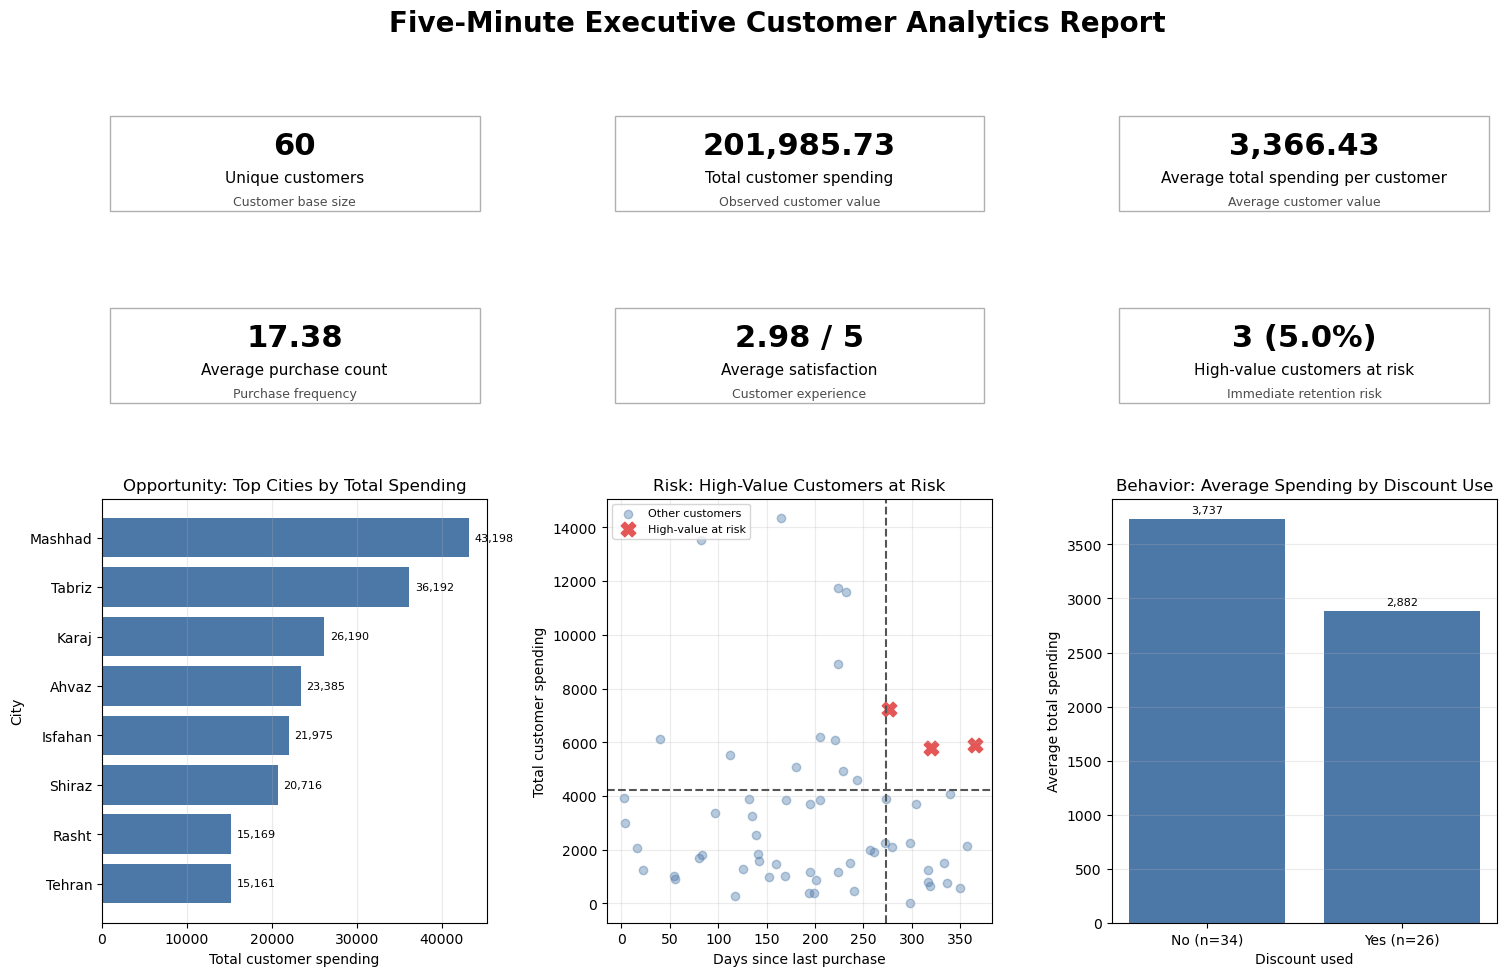

In [36]:
def plot_executive_dashboard(
    kpi_summary: pd.DataFrame,
    city_summary: pd.DataFrame,
    risk_df: pd.DataFrame,
    risk_thresholds: dict[str, float],
    discount_summary: pd.DataFrame,
    top_n_cities: int = 10,
) -> plt.Figure:
    """Create the one-page Question 6 executive dashboard.

    Args:
        kpi_summary: Six-row KPI table from build_management_kpi_summary().
        city_summary: Question 2 city-level metrics.
        risk_df: Question 4 customer table containing the at_risk flag.
        risk_thresholds: Question 4 value and inactivity thresholds.
        discount_summary: Question 5 discount-level metrics.
        top_n_cities: Maximum number of cities to show in the opportunity chart.

    Returns:
        The Matplotlib figure containing six KPI cards and three charts.
    """
    if len(kpi_summary) != 6:
        raise ValueError("The executive dashboard must contain exactly six KPIs.")
    if top_n_cities < 1:
        raise ValueError("top_n_cities must be at least 1.")

    fig = plt.figure(figsize=(18, 10.5))
    grid = fig.add_gridspec(
        nrows=3,
        ncols=6,
        height_ratios=[1.05, 1.05, 4.5],
        hspace=0.45,
        wspace=0.9,
    )
    fig.suptitle("Five-Minute Executive Customer Analytics Report", fontsize=20, fontweight="bold", y=0.98)

    # KPI cards: two rows of three cards.
    for index, row in kpi_summary.reset_index(drop=True).iterrows():
        card_row = index // 3
        card_col = (index % 3) * 2
        ax = fig.add_subplot(grid[card_row, card_col:card_col + 2])
        ax.axis("off")
        ax.text(0.5, 0.68, row["display_value"], ha="center", va="center", fontsize=22, fontweight="bold")
        ax.text(0.5, 0.36, row["kpi"], ha="center", va="center", fontsize=11)
        ax.text(0.5, 0.12, row["management_role"], ha="center", va="center", fontsize=9, alpha=0.7)
        ax.add_patch(
            plt.Rectangle(
                (0.02, 0.02),
                0.96,
                0.96,
                transform=ax.transAxes,
                fill=False,
                linewidth=1.0,
                edgecolor="#B0B0B0",
            )
        )

    # Chart 1: opportunity - top cities by total customer spending.
    city_ax = fig.add_subplot(grid[2, 0:2])
    city_chart = city_summary.nlargest(top_n_cities, "total_revenue").sort_values("total_revenue")
    city_labels = city_chart["city"]
    city_bars = city_ax.barh(city_labels, city_chart["total_revenue"], color="#4C78A8")
    for bar, value in zip(city_bars, city_chart["total_revenue"]):
        city_ax.annotate(
            f"{value:,.0f}",
            (bar.get_width(), bar.get_y() + bar.get_height() / 2),
            xytext=(4, 0),
            textcoords="offset points",
            va="center",
            fontsize=8,
        )
    city_ax.set_title("Opportunity: Top Cities by Total Spending")
    city_ax.set_xlabel("Total customer spending")
    city_ax.set_ylabel("City")
    city_ax.grid(axis="x", alpha=0.25)

    # Chart 2: risk - high-value inactive customers.
    risk_ax = fig.add_subplot(grid[2, 2:4])
    risk_ax.scatter(
        risk_df.loc[~risk_df["at_risk"], "last_purchase_days"],
        risk_df.loc[~risk_df["at_risk"], "total_spending"],
        alpha=0.40,
        color="#4C78A8",
        label="Other customers",
    )
    risk_ax.scatter(
        risk_df.loc[risk_df["at_risk"], "last_purchase_days"],
        risk_df.loc[risk_df["at_risk"], "total_spending"],
        marker="X",
        s=110,
        color="#E45756",
        label="High-value at risk",
    )
    risk_ax.axvline(risk_thresholds["inactivity_threshold"], linestyle="--", color="#555555")
    risk_ax.axhline(risk_thresholds["spending_threshold"], linestyle="--", color="#555555")
    risk_ax.set_title("Risk: High-Value Customers at Risk")
    risk_ax.set_xlabel("Days since last purchase")
    risk_ax.set_ylabel("Total customer spending")
    risk_ax.legend(fontsize=8)
    risk_ax.grid(alpha=0.25)

    # Chart 3: commercial behavior - spending by discount use.
    discount_ax = fig.add_subplot(grid[2, 4:6])
    discount_chart = discount_summary.sort_values("discount_used").copy()
    discount_labels = [
        f"{group} (n={int(count)})"
        for group, count in zip(discount_chart["discount_used"], discount_chart["customer_count"])
    ]
    discount_bars = discount_ax.bar(
        discount_labels,
        discount_chart["avg_total_spending"],
        color="#4C78A8",
    )
    for bar, value in zip(discount_bars, discount_chart["avg_total_spending"]):
        discount_ax.annotate(
            f"{value:,.0f}",
            (bar.get_x() + bar.get_width() / 2, bar.get_height()),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=8,
        )
    discount_ax.set_title("Behavior: Average Spending by Discount Use")
    discount_ax.set_xlabel("Discount used")
    discount_ax.set_ylabel("Average total spending")
    discount_ax.grid(axis="y", alpha=0.25)

    plt.show()
    return fig


executive_dashboard = plot_executive_dashboard(
    management_kpi_summary,
    city_summary,
    risk_df,
    risk_thresholds,
    discount_summary,
)


### 4. Optional Excel Export for the Final Project Deliverable

The project booklet also lists `customer_analytics_results.xlsx` as a final deliverable. The function below collects the main validated tables from Questions 2-6 into separate sheets. Export is disabled by default so rerunning the notebook does not overwrite an existing submission accidentally. Set `EXPORT_RESULTS = True` when you want to create or refresh the workbook.


In [37]:
RESULTS_WORKBOOK_PATH = PROJECT_ROOT / "customer_analytics_results.xlsx"


def export_analysis_tables_to_excel(output_path: Path) -> Path:
    """Export the main validated analysis tables to a multi-sheet Excel workbook.

    Args:
        output_path: Destination path for the Excel results workbook.

    Returns:
        The path of the generated workbook.
    """
    with pd.ExcelWriter(output_path) as writer:
        management_kpi_summary[["kpi", "value", "display_value", "management_role"]].to_excel(
            writer,
            sheet_name="KPI",
            index=False,
        )
        city_summary.to_excel(writer, sheet_name="City Analysis", index=False)
        top_loyal_customers.to_excel(writer, sheet_name="Top Loyal Customers", index=False)
        at_risk_customers.to_excel(writer, sheet_name="At Risk Customers", index=False)
        discount_summary.to_excel(writer, sheet_name="Discount Analysis", index=False)
        device_summary.to_excel(writer, sheet_name="Device Analysis", index=False)
        payment_summary.to_excel(writer, sheet_name="Payment Analysis", index=False)
        management_recommendations.to_excel(
            writer,
            sheet_name="Recommendations",
            index=False,
        )
    return output_path


EXPORT_RESULTS = False
if EXPORT_RESULTS:
    exported_results_path = export_analysis_tables_to_excel(RESULTS_WORKBOOK_PATH)
    print(f"Analysis results workbook saved to: {exported_results_path}")
else:
    print(
        "Excel export is ready. Set EXPORT_RESULTS = True in this cell to create "
        f"{RESULTS_WORKBOOK_PATH.name}."
    )


Excel export is ready. Set EXPORT_RESULTS = True in this cell to create customer_analytics_results.xlsx.


### 5. Executive Interpretation and Decision Logic

The overall customer base contains **60 unique customers** with **201,985.73** in observed total customer spending. Average total spending per customer is **3,366.43**, average purchase count is **17.38**, and average satisfaction is **2.98 / 5**. These values describe the current dataset, not a time-series trend, because the data contains one summarized row per customer rather than a full order history.

**Most important opportunity:** Question 2 ranks **Mashhad** first for advertising priority. It combines the highest city-level total spending (**43,197.58**) with **11 customers** and average customer spending of **3,927.05**. Its average satisfaction (**2.91**) is not the strongest city result, so the recommendation is a measured pilot with satisfaction monitoring rather than an unconditional budget shift.

**Most important risk:** Question 4 identifies **3 high-value customers at risk of inactivity**, representing **5.0%** of the customer base and **18,965.22** in combined historical spending. Two of the three have satisfaction scores of 1, so they should receive service recovery before a generic discount. The risk flag is based on observed inactivity and does not prove future churn.

**Commercial decision:** Question 5 shows that discount users have **22.9% lower average total spending** than non-users in the current sample, while their average returned-item count is also lower and their average satisfaction is higher. Therefore, the data does not justify expanding discounts on the assumption that discounts increase spending. A controlled test is the appropriate next step if management wants to estimate causal impact.


### 6. Limitations for the Executive Report

- Each row is a **customer-level summary**, so the report cannot analyze individual orders or changes over time.
- `last_purchase_days` gives only the distance from the latest purchase; it does not provide a complete purchase timeline, so churn cannot be proven.
- Discount comparisons are observational and **do not establish cause and effect**.
- `returned_items` is a count rather than a true return rate because the total number of purchased items is unavailable.
- Some city-level groups are small, so averages should be interpreted together with customer counts and not treated as perfectly stable estimates.


### 7. Final Answer for Question 6

The five-minute executive view should focus on three messages. First, the business currently has **60 customers** generating **201,985.73** in observed customer spending, with average satisfaction of **2.98 / 5**. Second, the strongest advertising opportunity is **Mashhad**, which leads city-level total spending at **43,197.58** across **11 customers**, but its moderate satisfaction score means investment should start as a measured pilot. Third, the most immediate customer risk is the group of **3 high-value inactive customers** with **18,965.22** in combined historical spending; two have low satisfaction and should receive service recovery before incentives.

For discount strategy, the current data does **not** show higher spending among discount users: their average total spending is about **22.9% lower** than the non-discount group, while their average returned-item count is also lower. Management should therefore avoid treating discounts as a proven sales driver and instead use a controlled experiment if causal impact needs to be measured.

The three recommended actions are: **(1)** test advertising investment in Mashhad with response and satisfaction KPIs, **(2)** immediately contact the three high-value at-risk customers using satisfaction-sensitive retention actions, and **(3)** test targeted discount offers rather than expanding discounts broadly. These recommendations are based on the observed customer-level dataset and should be refreshed when new customer activity becomes available.
